In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit


In [2]:
import pickle
with open('../both_sided_cuts/AOE_Classifier_r059.pkl',"rb") as f:
    new_obj = pickle.load(f)

In [3]:
runs = [
    's100ns_mw3', 's100ns_mw5', 's100ns_mw7',
    's200ns_mw3', 's200ns_mw5', 's200ns_mw7',
    # 's60ns_mw1',  's60ns_mw3',  's60ns_mw5',  's60ns_mw7','s100ns_mw1','s200ns_mw1',
]
A_max_mw_o_E_Classifier = new_obj['A_max_mw_o_E_Classifier']
ROI_mask = new_obj["ROI_mask"]

In [4]:
A_max_mw_o_E_Classifier.keys()

dict_keys(['s100ns_mw1', 's100ns_mw3', 's100ns_mw5', 's100ns_mw7', 's200ns_mw1', 's200ns_mw3', 's200ns_mw5', 's200ns_mw7', 's60ns_mw1', 's60ns_mw3', 's60ns_mw5', 's60ns_mw7'])

## aoe hists.

/tmp/ipykernel_2646590/3548949695.py:10: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


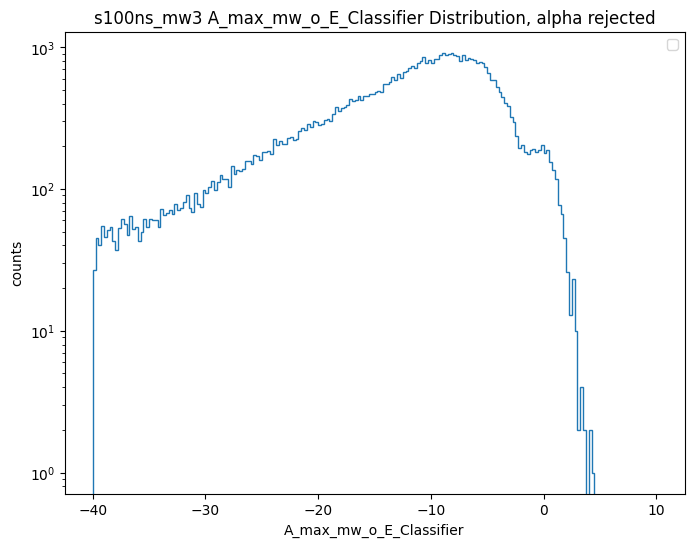

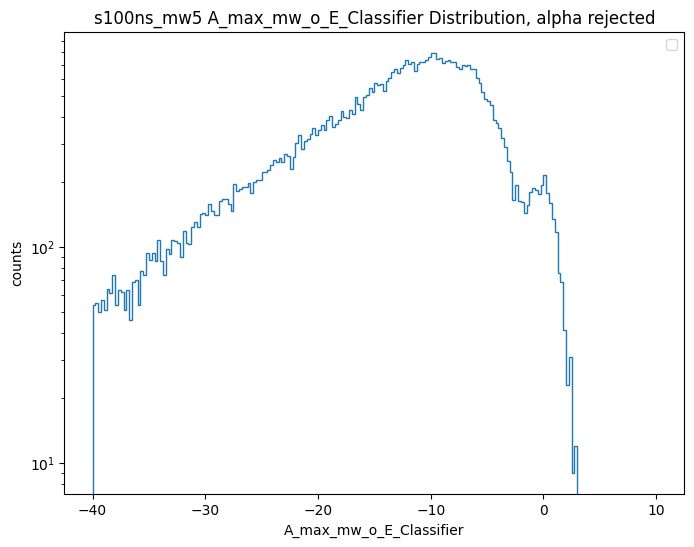

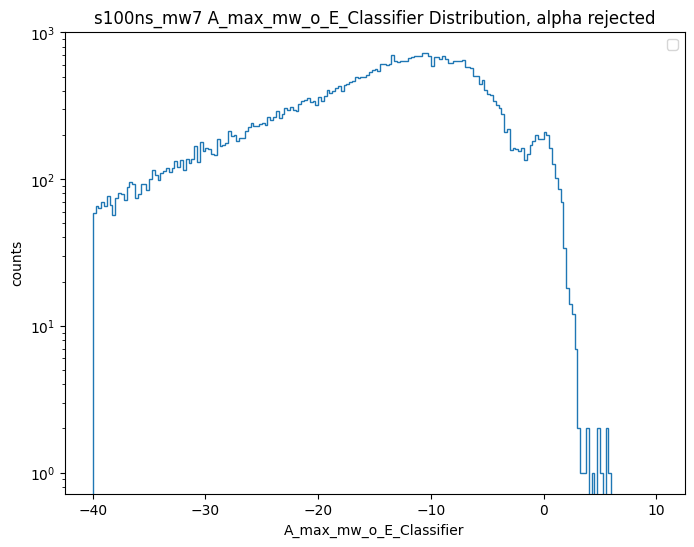

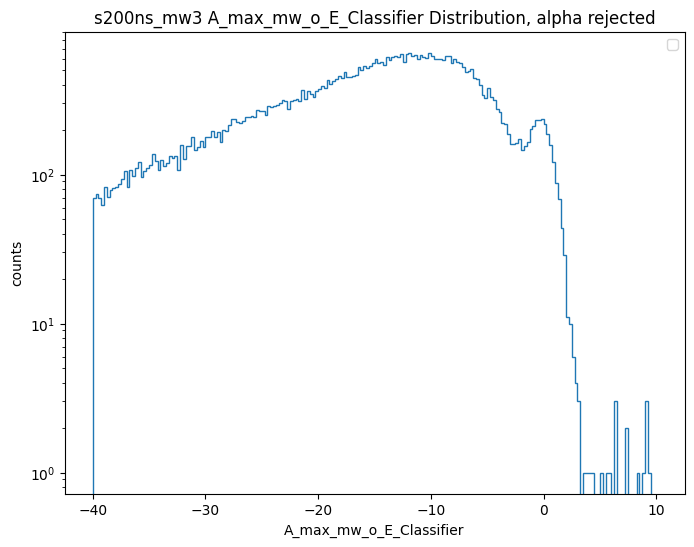

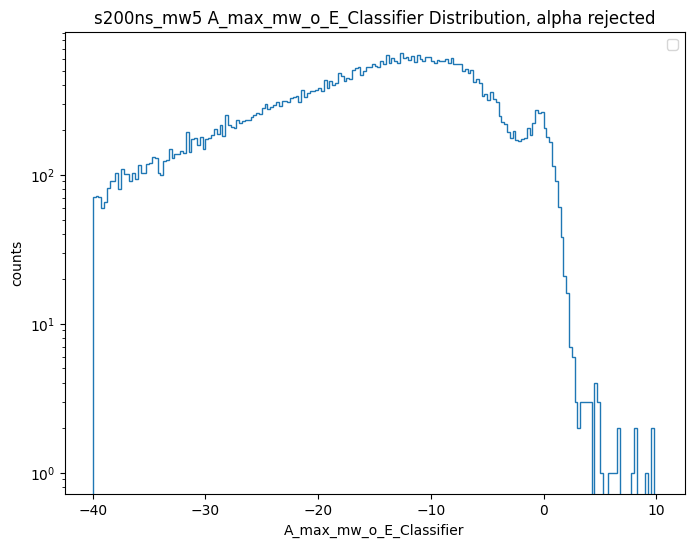

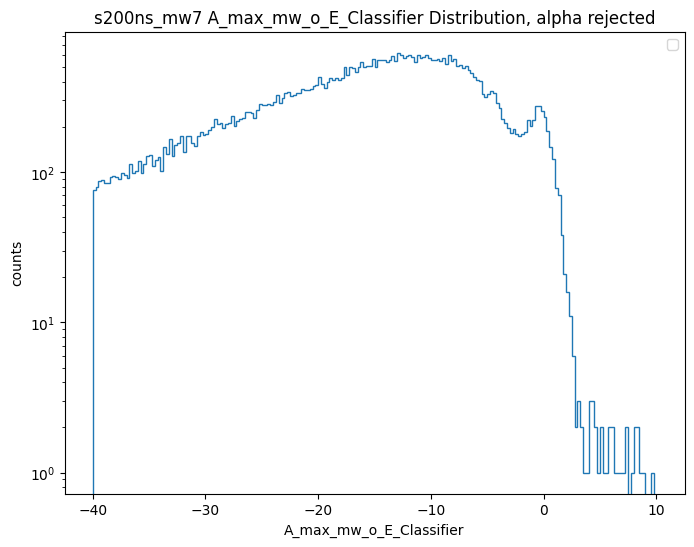

In [5]:
nbins = 200
range = (-40,10)
import matplotlib.pyplot as plt
for run in runs:
    fig,ax = plt.subplots(figsize=(8,6))
    ax.hist(A_max_mw_o_E_Classifier[run][ROI_mask], bins=nbins, range=range,histtype='step')
    # ax.hist(A_max_mw_o_E_Classifier[run][ROI_mask&A_max_mw_o_E_Low_Cut[run]], bins=nbins, range=range,histtype='step',label=f"{run} A_max_mw_o_E_Low_Cut")
    ax.set_xlabel("A_max_mw_o_E_Classifier")
    ax.set_ylabel("counts")
    ax.legend()
    ax.set_yscale('log')
    ax.set_title(f"{run} A_max_mw_o_E_Classifier Distribution, alpha rejected")
    plt.show()

## fits

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

def _propagate_uncertainty_numeric(func, popt, pcov, eps=1e-6):
    """
    Numerical Gaussian error propagation.

    func(p) must return one scalar quantity calculated from fit parameters p.
    sigma_f^2 = grad^T @ pcov @ grad
    """
    popt = np.asarray(popt, dtype=float)
    pcov = np.asarray(pcov, dtype=float)

    if pcov.shape != (len(popt), len(popt)):
        return np.nan

    if not np.all(np.isfinite(pcov)):
        return np.nan

    grad = np.zeros_like(popt, dtype=float)

    for i in range(len(popt)):
        step = eps * max(abs(popt[i]), 1.0)

        p_hi = popt.copy()
        p_lo = popt.copy()
        p_hi[i] += step
        p_lo[i] -= step

        grad[i] = (func(p_hi) - func(p_lo)) / (2 * step)

    var = float(grad @ pcov @ grad)

    if not np.isfinite(var) or var < 0:
        return np.nan

    return float(np.sqrt(var))
def _local_parabola_refit(
    centers,
    counts,
    coarse_idx,
    n_bins_refit=10,
    n_bins_left=None,
    n_bins_right=None,
    kind="peak",
    use_poisson_errors=True,
):
    """
    Refit a local parabola around a coarse peak/valley bin.

    kind:
        "peak"   -> expect downward parabola, a < 0
        "valley" -> expect upward parabola, a > 0

    Returns vertex position, vertex count, curvature, and their uncertainties.
    """
    centers = np.asarray(centers, dtype=float)
    counts = np.asarray(counts, dtype=float)
    if n_bins_left is None and n_bins_right is None:
        n_bins_left = n_bins_refit // 2
        n_bins_right = n_bins_refit - n_bins_left - 1

    elif n_bins_left is not None and n_bins_right is None:
        n_bins_right = n_bins_refit - n_bins_left - 1

    elif n_bins_left is None and n_bins_right is not None:
        n_bins_left = n_bins_refit - n_bins_right - 1

    if n_bins_left < 0 or n_bins_right < 0:
        raise ValueError(
            f"Invalid bin choice: n_bins_refit={n_bins_refit}, "
            f"n_bins_left={n_bins_left}, n_bins_right={n_bins_right}."
            )
    i0 = coarse_idx - n_bins_left
    i1 = coarse_idx + n_bins_right + 1

    # Edge handling: do not shift to preserve symmetry.
    # Just clip to valid histogram range.
    i0 = max(i0, 0)
    i1 = min(i1, len(centers))
    x = centers[i0:i1]
    y = counts[i0:i1]

    if len(x) < 3:
        raise ValueError("Need at least 3 bins for local parabola fit.")

    yerr = np.sqrt(np.maximum(y, 1.0)) if use_poisson_errors else None

    # shifted coordinate for numerical stability
    x0 = np.mean(x)
    u = x - x0

    def parabola_shifted(u, a, b, c):
        return a * u**2 + b * u + c

    p0 = np.polyfit(u, y, 2)

    popt, pcov = curve_fit(
        parabola_shifted,
        u,
        y,
        p0=p0,
        sigma=yerr,
        absolute_sigma=use_poisson_errors,
        maxfev=20000,
    )

    a, b, c = popt

    if np.isclose(a, 0):
        raise RuntimeError(f"{kind} parabola is almost flat; vertex unstable.")

    u_vertex = -b / (2 * a)
    x_vertex = x0 + u_vertex
    y_vertex = parabola_shifted(u_vertex, *popt)
    curvature = 2 * a

    # ---- uncertainty propagation from pcov ----
    def vertex_x_from_p(p):
        aa, bb, cc = p
        return x0 - bb / (2 * aa)

    def vertex_y_from_p(p):
        aa, bb, cc = p
        uu = -bb / (2 * aa)
        return aa * uu**2 + bb * uu + cc

    def curvature_from_p(p):
        aa, bb, cc = p
        return 2 * aa
    
    x_err = _propagate_uncertainty_numeric(vertex_x_from_p, popt, pcov)
    count_err = _propagate_uncertainty_numeric(vertex_y_from_p, popt, pcov)
    curvature_err = _propagate_uncertainty_numeric(curvature_from_p, popt, pcov)

    if kind == "peak" and a >= 0:
        print("[WARN] peak fit opens upward.")
    if kind == "valley" and a <= 0:
        print("[WARN] valley fit opens downward.")

    return {
        "x": float(x_vertex),
        "x_err": float(x_err),
        "n_bins_left": int(n_bins_left),
        "n_bins_right": int(n_bins_right),

        "count": float(y_vertex),
        "count_err": float(count_err),

        "curvature": float(curvature),
        "curvature_err": float(curvature_err),

        "a": float(a),
        "b": float(b),
        "c": float(c),
        "x0": float(x0),

        "coarse_x": float(centers[coarse_idx]),
        "coarse_count": float(counts[coarse_idx]),

        "fit_bin_indices": (int(i0), int(i1)),
        "fit_x": x,
        "fit_y": y,
        "fit_yerr": yerr,

        "popt": popt,
        "pcov": pcov,
    }

def _gaussian_peak(x, A, mu, sigma, C):
    return C + A * np.exp(-0.5 * ((x - mu) / sigma) ** 2)

def _gaussian_valley(x, A, mu, sigma, C):
    return C - A * np.exp(-0.5 * ((x - mu) / sigma) ** 2)

def _gaussian_fit_peak_or_valley(
    x_fit,
    y_fit,
    yerr_fit=None,
    kind="peak",
):
    """
    Gaussian refit using the same local bins as the parabola fit.

    Returns short internal keys:
        x, x_err, count, count_err, sigma, sigma_err, A, A_err, C, C_err
    """
    x_fit = np.asarray(x_fit, dtype=float)
    y_fit = np.asarray(y_fit, dtype=float)

    good = np.isfinite(x_fit) & np.isfinite(y_fit)

    if yerr_fit is not None:
        yerr_fit = np.asarray(yerr_fit, dtype=float)
        good &= np.isfinite(yerr_fit) & (yerr_fit > 0)

    x_fit = x_fit[good]
    y_fit = y_fit[good]

    if yerr_fit is not None:
        yerr_fit = yerr_fit[good]

    fail = {
        "x": np.nan,
        "x_err": np.nan,
        "count": np.nan,
        "count_err": np.nan,
        "sigma": np.nan,
        "sigma_err": np.nan,
        "A": np.nan,
        "A_err": np.nan,
        "C": np.nan,
        "C_err": np.nan,
        "popt": None,
        "pcov": None,
        "success": False,
    }

    if len(x_fit) < 4:
        return fail.copy()

    x_min = float(np.min(x_fit))
    x_max = float(np.max(x_fit))
    dx = x_max - x_min

    if dx <= 0:
        return fail.copy()

    C0 = float(np.median(y_fit))

    if kind == "peak":
        model = _gaussian_peak
        mu0 = float(x_fit[np.argmax(y_fit)])
        A0 = float(np.max(y_fit) - C0)
    elif kind == "valley":
        model = _gaussian_valley
        mu0 = float(x_fit[np.argmin(y_fit)])
        A0 = float(C0 - np.min(y_fit))
    else:
        raise ValueError("kind must be 'peak' or 'valley'")

    A0 = max(A0, 1.0)
    sigma0 = dx / 4.0

    lower = [0.0, x_min, dx / 100.0, 0.0]
    upper = [np.inf, x_max, dx * 2.0, np.inf]

    try:
        popt, pcov = curve_fit(
            model,
            x_fit,
            y_fit,
            p0=[A0, mu0, sigma0, C0],
            sigma=yerr_fit,
            absolute_sigma=(yerr_fit is not None),
            bounds=(lower, upper),
            maxfev=20000,
        )

        A, mu, sigma, C = popt

        if pcov is None or not np.all(np.isfinite(pcov)):
            perr = np.full(4, np.nan)
        else:
            perr = np.sqrt(np.diag(pcov))

        # count at fitted center
        count = float(model(mu, *popt))

        def count_from_p(p):
            A_, mu_, sigma_, C_ = p
            return model(mu_, A_, mu_, sigma_, C_)

        count_err = _propagate_uncertainty_numeric(count_from_p, popt, pcov)

        return {
            "x": float(mu),
            "x_err": float(perr[1]),
            "count": float(count),
            "count_err": float(count_err),
            "sigma": abs(float(sigma)),
            "sigma_err": float(perr[2]),
            "A": float(A),
            "A_err": float(perr[0]),
            "C": float(C),
            "C_err": float(perr[3]),
            "popt": popt,
            "pcov": pcov,
            "success": True,
        }

    except Exception as e:
        print(f"[WARN] {kind} gaussian fit failed: {e}")
        return fail.copy()

def relative_prominence_and_error(P, V, P_err, V_err):
    """
    Relative prominence:
        R = (P - V) / P = 1 - V/P
    """
    if not np.isfinite(P) or not np.isfinite(V) or P <= 0:
        return np.nan, np.nan

    R = (P - V) / P

    R_err = np.sqrt(
        (V / P**2 * P_err) ** 2
        + (V_err / P) ** 2
    )

    return float(R), float(R_err)

def peak_to_valley_and_error(P, V, P_err, V_err):
    """
    Peak-to-valley ratio:
        PVR = P / V
    """
    if not np.isfinite(P) or not np.isfinite(V) or P <= 0 or V <= 0:
        return np.nan, np.nan

    PVR = P / V

    PVR_err = PVR * np.sqrt(
        (P_err / P) ** 2
        + (V_err / V) ** 2
    )

    return float(PVR), float(PVR_err)

def peak_valley_refit_from_data(
    aoe_data,
    counts_key="counts",
    peak_range=(-2, 3),
    valley_range=(-5, -2),
    nbins=300,
    hist_range=(-40, 40),
    n_bins_refit=10,
    peak_bins_left=None,
    peak_bins_right=None,
    valley_bins_left=None,
    valley_bins_right=None,
    use_poisson_errors=True,
    plot_parabola=True,
    plot_gaussian=True,
    title=None,
):
    """
    Find peak and valley from a histogram and refit locally.

    Returns both:
        relative_prominence = (peak - valley) / peak
        peak_to_valley      = peak / valley

    The plot labels and returned values use the same fitted counts.
    """

    # ------------------------------------------------------------
    # Histogram
    # ------------------------------------------------------------
    counts, edges = np.histogram(
        aoe_data,
        bins=nbins,
        range=hist_range,
    )

    centers = 0.5 * (edges[:-1] + edges[1:])
    bin_width = np.median(np.diff(edges))

    # ------------------------------------------------------------
    # Find coarse peak and valley bins
    # ------------------------------------------------------------
    peak_mask = (centers >= peak_range[0]) & (centers <= peak_range[1])
    valley_mask = (centers >= valley_range[0]) & (centers <= valley_range[1])

    if np.count_nonzero(peak_mask) < 3:
        raise ValueError("Not enough bins in peak_range.")

    if np.count_nonzero(valley_mask) < 3:
        raise ValueError("Not enough bins in valley_range.")

    peak_indices = np.where(peak_mask)[0]
    valley_indices = np.where(valley_mask)[0]

    coarse_peak_idx = peak_indices[np.argmax(counts[peak_mask])]
    coarse_valley_idx = valley_indices[np.argmin(counts[valley_mask])]

    # ------------------------------------------------------------
    # Local parabola refits
    # ------------------------------------------------------------
    peak_fit = _local_parabola_refit(
        centers=centers,
        counts=counts,
        coarse_idx=coarse_peak_idx,
        n_bins_refit=n_bins_refit,
        n_bins_left=peak_bins_left,
        n_bins_right=peak_bins_right,
        kind="peak",
        use_poisson_errors=use_poisson_errors,
    )

    valley_fit = _local_parabola_refit(
        centers=centers,
        counts=counts,
        coarse_idx=coarse_valley_idx,
        n_bins_refit=n_bins_refit,
        n_bins_left=valley_bins_left,
        n_bins_right=valley_bins_right,
        kind="valley",
        use_poisson_errors=use_poisson_errors,
    )

    # ------------------------------------------------------------
    # Gaussian refits on the same local bins
    # ------------------------------------------------------------
    peak_g = _gaussian_fit_peak_or_valley(
        peak_fit["fit_x"],
        peak_fit["fit_y"],
        peak_fit["fit_yerr"] if use_poisson_errors else None,
        kind="peak",
    )

    valley_g = _gaussian_fit_peak_or_valley(
        valley_fit["fit_x"],
        valley_fit["fit_y"],
        valley_fit["fit_yerr"] if use_poisson_errors else None,
        kind="valley",
    )

    # ------------------------------------------------------------
    # Parabola metrics
    # ------------------------------------------------------------
    P = peak_fit["count"]
    P_err = peak_fit["count_err"]

    V = valley_fit["count"]
    V_err = valley_fit["count_err"]

    rel_prom, rel_prom_err = relative_prominence_and_error(P, V, P_err, V_err)
    pvr, pvr_err = peak_to_valley_and_error(P, V, P_err, V_err)

    # ------------------------------------------------------------
    # Gaussian metrics
    # ------------------------------------------------------------
    Pg = peak_g["count"]
    Pg_err = peak_g["count_err"]

    Vg = valley_g["count"]
    Vg_err = valley_g["count_err"]

    rel_prom_g, rel_prom_err_g = relative_prominence_and_error(
        Pg, Vg, Pg_err, Vg_err
    )

    pvr_g, pvr_err_g = peak_to_valley_and_error(
        Pg, Vg, Pg_err, Vg_err
    )

    # ------------------------------------------------------------
    # Plot
    # ------------------------------------------------------------
    if plot_parabola or plot_gaussian:

        def eval_parabola(x, fit):
            u = x - fit["x0"]
            a, b, c = fit["popt"]
            return a * u**2 + b * u + c

        fig, ax = plt.subplots(figsize=(8, 5))

        # Same histogram binning everywhere
        ax.stairs(
            counts,
            edges,
            label=f"hist {counts_key}",
            alpha=0.75,
        )

        # Fit-window boundaries
        peak_xmin = peak_fit["fit_x"][0] - bin_width / 2
        peak_xmax = peak_fit["fit_x"][-1] + bin_width / 2

        valley_xmin = valley_fit["fit_x"][0] - bin_width / 2
        valley_xmax = valley_fit["fit_x"][-1] + bin_width / 2

        ax.axvspan(
            peak_xmin,
            peak_xmax,
            alpha=0.25,
            label=f"peak fit range ({len(peak_fit['fit_x'])} bins)",
        )

        ax.axvspan(
            valley_xmin,
            valley_xmax,
            alpha=0.20,
            label=f"valley fit range ({len(valley_fit['fit_x'])} bins)",
        )

        xp = np.linspace(peak_xmin, peak_xmax, 300)
        xv = np.linspace(valley_xmin, valley_xmax, 300)

        y_candidates = list(counts[np.isfinite(counts)])

        # -------------------------
        # Parabola curves
        # -------------------------
        if plot_parabola:
            yp = eval_parabola(xp, peak_fit)
            yv = eval_parabola(xv, valley_fit)

            ax.plot(xp, yp, linewidth=2, alpha=0.5, label="peak parabola")
            ax.plot(xv, yv, linewidth=2, alpha=0.5, label="valley parabola")

            ax.axvline(
                peak_fit["x"],
                linestyle="--",
                label=(
                    f"peak parabola: x={peak_fit['x']:.3f}, "
                    f"P={P:.1f} ± {P_err:.1f}"
                ),
            )

            ax.axvline(
                valley_fit["x"],
                linestyle="--",
                label=(
                    f"valley parabola: x={valley_fit['x']:.3f}, "
                    f"V={V:.1f} ± {V_err:.1f}"
                ),
            )

            y_candidates.extend(yp[np.isfinite(yp)])
            y_candidates.extend(yv[np.isfinite(yv)])

        # -------------------------
        # Gaussian curves
        # -------------------------
        if plot_gaussian:
            if peak_g["success"]:
                ypg = _gaussian_peak(xp, *peak_g["popt"])

                ax.plot(
                    xp,
                    ypg,
                    linewidth=2,
                    linestyle="-",
                    alpha=0.8,
                    label="peak gaussian",
                )

                ax.axvline(
                    peak_g["x"],
                    linestyle=":",
                    label=(
                        f"peak gaussian: x={peak_g['x']:.3f}, "
                        f"P={Pg:.1f} ± {Pg_err:.1f}"
                    ),
                )

                y_candidates.extend(ypg[np.isfinite(ypg)])

            if valley_g["success"]:
                yvg = _gaussian_valley(xv, *valley_g["popt"])

                ax.plot(
                    xv,
                    yvg,
                    linewidth=2,
                    linestyle="-",
                    alpha=0.8,
                    label="valley gaussian",
                )

                ax.axvline(
                    valley_g["x"],
                    linestyle=":",
                    label=(
                        f"valley gaussian: x={valley_g['x']:.3f}, "
                        f"V={Vg:.1f} ± {Vg_err:.1f}"
                    ),
                )

                y_candidates.extend(yvg[np.isfinite(yvg)])

        # ------------------------------------------------------------
        # Inset
        # ------------------------------------------------------------
        inset_xmin = min(peak_xmin, valley_xmin)
        inset_xmax = max(peak_xmax, valley_xmax)

        inset_dx = inset_xmax - inset_xmin
        inset_xmin -= 0.10 * inset_dx
        inset_xmax += 0.10 * inset_dx

        axins = ax.inset_axes([0.05, 0.05, 0.38, 0.32])

        # Important: exact same histogram and binning
        axins.stairs(
            counts,
            edges,
            alpha=0.75,
        )

        axins.axvspan(peak_xmin, peak_xmax, alpha=0.25)
        axins.axvspan(valley_xmin, valley_xmax, alpha=0.20)

        inset_y_candidates = []

        inset_mask = (centers >= inset_xmin) & (centers <= inset_xmax)
        inset_y_candidates.extend(counts[inset_mask])

        if plot_parabola:
            axins.plot(xp, yp, linewidth=1.7, alpha=0.5)
            axins.plot(xv, yv, linewidth=1.7, alpha=0.5)
            axins.axvline(peak_fit["x"], linestyle="--", linewidth=1.2)
            axins.axvline(valley_fit["x"], linestyle="--", linewidth=1.2)

            inset_y_candidates.extend(yp[np.isfinite(yp)])
            inset_y_candidates.extend(yv[np.isfinite(yv)])

        if plot_gaussian:
            if peak_g["success"]:
                axins.plot(xp, ypg, linewidth=1.7, alpha=0.8)
                axins.axvline(peak_g["x"], linestyle=":", linewidth=1.3)
                inset_y_candidates.extend(ypg[np.isfinite(ypg)])

            if valley_g["success"]:
                axins.plot(xv, yvg, linewidth=1.7, alpha=0.8)
                axins.axvline(valley_g["x"], linestyle=":", linewidth=1.3)
                inset_y_candidates.extend(yvg[np.isfinite(yvg)])

        inset_y_candidates = np.asarray(inset_y_candidates, dtype=float)
        inset_y_candidates = inset_y_candidates[np.isfinite(inset_y_candidates)]

        if len(inset_y_candidates) > 0:
            ymin = np.min(inset_y_candidates)
            ymax = np.max(inset_y_candidates)
            dy = ymax - ymin

            if dy <= 0:
                dy = max(abs(ymax), 1.0) * 0.2

            inset_ymin = max(0.0, ymin - 0.15 * dy)
            inset_ymax = ymax + 0.20 * dy
        else:
            inset_ymin, inset_ymax = 0.0, 1.0

        axins.set_xlim(inset_xmin, inset_xmax)
        axins.set_ylim(inset_ymin, inset_ymax)
        axins.grid(alpha=0.25)
        axins.tick_params(labelsize=7)
        axins.xaxis.set_major_locator(MaxNLocator(4))
        axins.yaxis.set_major_locator(MaxNLocator(4))
        axins.set_title("fit zoom", fontsize=8)

        # ------------------------------------------------------------
        # Main plot style
        # ------------------------------------------------------------
        ax.set_xlabel("A/E")
        ax.set_ylabel("Counts")
        ax.set_yscale("log")
        ax.grid(alpha=0.3)

        if title is None:
            title_use = "Peak-valley fit"
        else:
            title_use = f"{title}\nPeak-valley fit"

        metric_lines = [
            f"Parabola: rel. prom. = {rel_prom:.3f} ± {rel_prom_err:.3f}, "
            f"P/V = {pvr:.2f} ± {pvr_err:.2f}"
        ]

        if peak_g["success"] and valley_g["success"]:
            metric_lines.append(
                f"Gaussian: rel. prom. = {rel_prom_g:.3f} ± {rel_prom_err_g:.3f}, "
                f"P/V = {pvr_g:.2f} ± {pvr_err_g:.2f}"
            )

        ax.set_title(title_use + "\n" + "\n".join(metric_lines))

        ax.legend(
            fontsize=8,
            loc="upper right",
            bbox_to_anchor=(0.98, 0.98),
        )

        fig.tight_layout()
        plt.show()

    # ------------------------------------------------------------
    # Return clean result dictionary
    # ------------------------------------------------------------
    return {
        # Main useful metrics
        "relative_prominence": rel_prom,
        "relative_prominence_err": rel_prom_err,
        "peak_to_valley": pvr,
        "peak_to_valley_err": pvr_err,

        "relative_prominence_gaussian": rel_prom_g,
        "relative_prominence_err_gaussian": rel_prom_err_g,
        "peak_to_valley_gaussian": pvr_g,
        "peak_to_valley_err_gaussian": pvr_err_g,

        # Parabola fit results
        "peak_x": peak_fit["x"],
        "peak_x_err": peak_fit["x_err"],
        "peak_count": P,
        "peak_count_err": P_err,

        "valley_x": valley_fit["x"],
        "valley_x_err": valley_fit["x_err"],
        "valley_count": V,
        "valley_count_err": V_err,

        "peak_curvature": peak_fit["curvature"],
        "peak_curvature_err": peak_fit["curvature_err"],
        "valley_curvature": valley_fit["curvature"],
        "valley_curvature_err": valley_fit["curvature_err"],

        # Gaussian fit results
        "peak_x_gaussian": peak_g["x"],
        "peak_x_err_gaussian": peak_g["x_err"],
        "peak_count_gaussian": Pg,
        "peak_count_err_gaussian": Pg_err,
        "peak_sigma_gaussian": peak_g["sigma"],
        "peak_sigma_err_gaussian": peak_g["sigma_err"],
        "peak_A_gaussian": peak_g["A"],
        "peak_A_err_gaussian": peak_g["A_err"],
        "peak_C_gaussian": peak_g["C"],
        "peak_C_err_gaussian": peak_g["C_err"],
        "peak_fit_success_gaussian": peak_g["success"],

        "valley_x_gaussian": valley_g["x"],
        "valley_x_err_gaussian": valley_g["x_err"],
        "valley_count_gaussian": Vg,
        "valley_count_err_gaussian": Vg_err,
        "valley_sigma_gaussian": valley_g["sigma"],
        "valley_sigma_err_gaussian": valley_g["sigma_err"],
        "valley_A_gaussian": valley_g["A"],
        "valley_A_err_gaussian": valley_g["A_err"],
        "valley_C_gaussian": valley_g["C"],
        "valley_C_err_gaussian": valley_g["C_err"],
        "valley_fit_success_gaussian": valley_g["success"],

        # Debug / reproducibility
        "counts_key": counts_key,
        "nbins": nbins,
        "hist_range": hist_range,
        "peak_range": peak_range,
        "valley_range": valley_range,
        "n_bins_refit": n_bins_refit,

        "peak_fit": peak_fit,
        "valley_fit": valley_fit,
        "peak_fit_gaussian": peak_g,
        "valley_fit_gaussian": valley_g,
    }

In [7]:
import numpy as np
import matplotlib.pyplot as plt

from scipy.optimize import curve_fit
from matplotlib.ticker import MaxNLocator


def peak_valley_parabola_refit_from_hist_item(
    aoe_data,
    counts_key="counts",
    peak_range=(-0.5, 3),
    valley_range=(-5, -1),
    nbins=300,
    hist_range=(-40, 40),
    n_bins_refit=10,
    peak_bins_left=None,
    peak_bins_right=None,
    valley_bins_left=None,
    valley_bins_right=None,
    use_poisson_errors=True,
    plot_gaus=False,
    plot=False,
    title=None,
):
    """
    Peak/valley figure of merit from a histogram of A/E-classifier values.

    Important definitions:
        P = fitted peak height
        V = fitted valley height

        ratio = prominence_rel = (P - V) / P
        peak_to_valley = P / V

    The quantity called "ratio" is kept for compatibility with your old code,
    but mathematically it is relative prominence, not P/V.
    """

    aoe_data = np.asarray(aoe_data, dtype=float)
    aoe_data = aoe_data[np.isfinite(aoe_data)]

    counts, edges = np.histogram(
        aoe_data,
        bins=nbins,
        range=hist_range,
    )

    centers = 0.5 * (edges[:-1] + edges[1:])
    bin_width = np.median(np.diff(centers))

    # ------------------------------------------------------------
    # small internal utility: numerical error propagation
    # ------------------------------------------------------------
    def propagate_uncertainty_numeric(func, popt, pcov, eps=1e-6):
        popt = np.asarray(popt, dtype=float)
        pcov = np.asarray(pcov, dtype=float)

        if pcov.shape != (len(popt), len(popt)):
            return np.nan

        if not np.all(np.isfinite(pcov)):
            return np.nan

        grad = np.zeros_like(popt, dtype=float)

        for i in range(len(popt)):
            step = eps * max(abs(popt[i]), 1.0)

            p_hi = popt.copy()
            p_lo = popt.copy()

            p_hi[i] += step
            p_lo[i] -= step

            grad[i] = (func(p_hi) - func(p_lo)) / (2 * step)

        var = float(grad @ pcov @ grad)

        if not np.isfinite(var) or var < 0:
            return np.nan

        return float(np.sqrt(var))

    # ------------------------------------------------------------
    # local parabola refit
    # ------------------------------------------------------------
    def local_parabola_refit(
        centers,
        counts,
        coarse_idx,
        n_bins_refit=10,
        n_bins_left=None,
        n_bins_right=None,
        kind="peak",
        use_poisson_errors=True,
    ):
        if n_bins_left is None and n_bins_right is None:
            n_bins_left = n_bins_refit // 2
            n_bins_right = n_bins_refit - n_bins_left - 1

        elif n_bins_left is not None and n_bins_right is None:
            n_bins_right = n_bins_refit - n_bins_left - 1

        elif n_bins_left is None and n_bins_right is not None:
            n_bins_left = n_bins_refit - n_bins_right - 1

        if n_bins_left < 0 or n_bins_right < 0:
            raise ValueError("Invalid refit bin choice.")

        i0 = max(coarse_idx - n_bins_left, 0)
        i1 = min(coarse_idx + n_bins_right + 1, len(centers))

        x = centers[i0:i1]
        y = counts[i0:i1]

        if len(x) < 3:
            raise ValueError("Need at least 3 bins for local parabola fit.")

        yerr = np.sqrt(np.maximum(y, 1.0)) if use_poisson_errors else None

        x0 = np.mean(x)
        u = x - x0

        def parabola_shifted(u, a, b, c):
            return a * u**2 + b * u + c

        p0 = np.polyfit(u, y, 2)

        popt, pcov = curve_fit(
            parabola_shifted,
            u,
            y,
            p0=p0,
            sigma=yerr,
            absolute_sigma=use_poisson_errors,
            maxfev=20000,
        )

        a, b, c = popt

        if np.isclose(a, 0):
            raise RuntimeError(f"{kind} parabola is almost flat.")

        u_vertex = -b / (2 * a)
        x_vertex = x0 + u_vertex
        y_vertex = parabola_shifted(u_vertex, *popt)
        curvature = 2 * a

        def vertex_x_from_p(p):
            aa, bb, cc = p
            return x0 - bb / (2 * aa)

        def vertex_y_from_p(p):
            aa, bb, cc = p
            uu = -bb / (2 * aa)
            return aa * uu**2 + bb * uu + cc

        def curvature_from_p(p):
            aa, bb, cc = p
            return 2 * aa

        x_err = propagate_uncertainty_numeric(vertex_x_from_p, popt, pcov)
        count_err = propagate_uncertainty_numeric(vertex_y_from_p, popt, pcov)
        curvature_err = propagate_uncertainty_numeric(curvature_from_p, popt, pcov)

        if kind == "peak" and a >= 0:
            print("[WARN] peak parabola opens upward.")
        if kind == "valley" and a <= 0:
            print("[WARN] valley parabola opens downward.")

        return {
            "x": float(x_vertex),
            "x_err": float(x_err),
            "count": float(y_vertex),
            "count_err": float(count_err),
            "curvature": float(curvature),
            "curvature_err": float(curvature_err),
            "coarse_x": float(centers[coarse_idx]),
            "coarse_count": float(counts[coarse_idx]),
            "fit_x": x,
            "fit_y": y,
            "fit_yerr": yerr,
            "x0": float(x0),
            "popt": popt,
            "pcov": pcov,
            "n_bins_left": int(n_bins_left),
            "n_bins_right": int(n_bins_right),
        }

    # ------------------------------------------------------------
    # Gaussian models
    # ------------------------------------------------------------
    def gaussian_peak(x, A, mu, sigma, C):
        return C + A * np.exp(-0.5 * ((x - mu) / sigma) ** 2)

    def gaussian_valley(x, A, mu, sigma, C):
        return C - A * np.exp(-0.5 * ((x - mu) / sigma) ** 2)

    def gaussian_fit_peak_or_valley(x, y, yerr=None, kind="peak"):
        x = np.asarray(x, dtype=float)
        y = np.asarray(y, dtype=float)

        try:
            if kind == "peak":
                idx = np.argmax(y)
                mu0 = x[idx]
                C0 = np.min(y)
                A0 = max(np.max(y) - C0, 1.0)
                sigma0 = max(2 * bin_width, np.std(x))

                p0 = [A0, mu0, sigma0, C0]
                bounds = (
                    [0.0, x.min(), bin_width / 10, 0.0],
                    [np.inf, x.max(), np.inf, np.inf],
                )

                popt, pcov = curve_fit(
                    gaussian_peak,
                    x,
                    y,
                    p0=p0,
                    sigma=yerr,
                    absolute_sigma=(yerr is not None),
                    bounds=bounds,
                    maxfev=20000,
                )

                A, mu, sigma, C = popt
                count = C + A

                def count_from_p(p):
                    AA, mm, ss, CC = p
                    return CC + AA

            else:
                idx = np.argmin(y)
                mu0 = x[idx]
                C0 = np.max(y)
                A0 = max(C0 - np.min(y), 1.0)
                sigma0 = max(2 * bin_width, np.std(x))

                p0 = [A0, mu0, sigma0, C0]
                bounds = (
                    [0.0, x.min(), bin_width / 10, 0.0],
                    [np.inf, x.max(), np.inf, np.inf],
                )

                popt, pcov = curve_fit(
                    gaussian_valley,
                    x,
                    y,
                    p0=p0,
                    sigma=yerr,
                    absolute_sigma=(yerr is not None),
                    bounds=bounds,
                    maxfev=20000,
                )

                A, mu, sigma, C = popt
                count = C - A

                def count_from_p(p):
                    AA, mm, ss, CC = p
                    return CC - AA

            A, mu, sigma, C = popt

            A_err = np.sqrt(pcov[0, 0]) if np.isfinite(pcov[0, 0]) else np.nan
            mu_err = np.sqrt(pcov[1, 1]) if np.isfinite(pcov[1, 1]) else np.nan
            sigma_err = np.sqrt(pcov[2, 2]) if np.isfinite(pcov[2, 2]) else np.nan
            C_err = np.sqrt(pcov[3, 3]) if np.isfinite(pcov[3, 3]) else np.nan
            count_err = propagate_uncertainty_numeric(count_from_p, popt, pcov)

            return {
                "success": True,
                "x": float(mu),
                "x_err": float(mu_err),
                "count": float(count),
                "count_err": float(count_err),
                "sigma": float(sigma),
                "sigma_err": float(sigma_err),
                "A": float(A),
                "A_err": float(A_err),
                "C": float(C),
                "C_err": float(C_err),
                "popt": popt,
                "pcov": pcov,
            }

        except Exception as err:
            print(f"[WARN] Gaussian {kind} fit failed: {err}")

            return {
                "success": False,
                "x": np.nan,
                "x_err": np.nan,
                "count": np.nan,
                "count_err": np.nan,
                "sigma": np.nan,
                "sigma_err": np.nan,
                "A": np.nan,
                "A_err": np.nan,
                "C": np.nan,
                "C_err": np.nan,
                "popt": None,
                "pcov": None,
            }

    # ------------------------------------------------------------
    # find coarse peak and valley bins
    # ------------------------------------------------------------
    peak_mask = (centers >= peak_range[0]) & (centers <= peak_range[1])
    valley_mask = (centers >= valley_range[0]) & (centers <= valley_range[1])

    if np.count_nonzero(peak_mask) < 3:
        raise ValueError("Not enough bins in peak_range.")

    if np.count_nonzero(valley_mask) < 3:
        raise ValueError("Not enough bins in valley_range.")

    peak_indices = np.where(peak_mask)[0]
    valley_indices = np.where(valley_mask)[0]

    coarse_peak_idx = peak_indices[np.argmax(counts[peak_mask])]
    coarse_valley_idx = valley_indices[np.argmin(counts[valley_mask])]

    peak_fit = local_parabola_refit(
        centers=centers,
        counts=counts,
        coarse_idx=coarse_peak_idx,
        n_bins_refit=n_bins_refit,
        n_bins_left=peak_bins_left,
        n_bins_right=peak_bins_right,
        kind="peak",
        use_poisson_errors=use_poisson_errors,
    )

    valley_fit = local_parabola_refit(
        centers=centers,
        counts=counts,
        coarse_idx=coarse_valley_idx,
        n_bins_refit=n_bins_refit,
        n_bins_left=valley_bins_left,
        n_bins_right=valley_bins_right,
        kind="valley",
        use_poisson_errors=use_poisson_errors,
    )

    peak_g = gaussian_fit_peak_or_valley(
        peak_fit["fit_x"],
        peak_fit["fit_y"],
        peak_fit["fit_yerr"] if use_poisson_errors else None,
        kind="peak",
    )

    valley_g = gaussian_fit_peak_or_valley(
        valley_fit["fit_x"],
        valley_fit["fit_y"],
        valley_fit["fit_yerr"] if use_poisson_errors else None,
        kind="valley",
    )

    # ------------------------------------------------------------
    # mathematically clean parabola metrics
    # ------------------------------------------------------------
    P = peak_fit["count"]
    P_err = peak_fit["count_err"]

    V = valley_fit["count"]
    V_err = valley_fit["count_err"]

    prominence_abs = P - V
    prominence_abs_err = np.sqrt(P_err**2 + V_err**2)

    prominence_rel = (P - V) / P
    prominence_rel_err = np.sqrt(
        (V / P**2 * P_err) ** 2
        + (V_err / P) ** 2
    )

    peak_to_valley = P / V
    peak_to_valley_err = peak_to_valley * np.sqrt(
        (P_err / P) ** 2
        + (V_err / V) ** 2
    )

    contrast_to_valley = (P - V) / V
    contrast_to_valley_err = peak_to_valley_err

    # ------------------------------------------------------------
    # mathematically clean Gaussian metrics
    # ------------------------------------------------------------
    P_g = peak_g["count"]
    P_g_err = peak_g["count_err"]

    V_g = valley_g["count"]
    V_g_err = valley_g["count_err"]

    if (
        np.isfinite(P_g)
        and np.isfinite(P_g_err)
        and np.isfinite(V_g)
        and np.isfinite(V_g_err)
        and P_g > 0
        and V_g > 0
    ):
        prominence_abs_gaussian = P_g - V_g
        prominence_abs_err_gaussian = np.sqrt(P_g_err**2 + V_g_err**2)

        prominence_rel_gaussian = (P_g - V_g) / P_g
        prominence_rel_err_gaussian = np.sqrt(
            (V_g / P_g**2 * P_g_err) ** 2
            + (V_g_err / P_g) ** 2
        )

        peak_to_valley_gaussian = P_g / V_g
        peak_to_valley_err_gaussian = peak_to_valley_gaussian * np.sqrt(
            (P_g_err / P_g) ** 2
            + (V_g_err / V_g) ** 2
        )

        contrast_to_valley_gaussian = (P_g - V_g) / V_g
        contrast_to_valley_err_gaussian = peak_to_valley_err_gaussian

    else:
        prominence_abs_gaussian = np.nan
        prominence_abs_err_gaussian = np.nan
        prominence_rel_gaussian = np.nan
        prominence_rel_err_gaussian = np.nan
        peak_to_valley_gaussian = np.nan
        peak_to_valley_err_gaussian = np.nan
        contrast_to_valley_gaussian = np.nan
        contrast_to_valley_err_gaussian = np.nan

    # ------------------------------------------------------------
    # plotting
    # ------------------------------------------------------------
    if plot or plot_gaus:
        fig, ax = plt.subplots(figsize=(8, 5))

        ax.step(
            centers,
            counts,
            where="mid",
            label=f"hist {counts_key}",
            alpha=0.75,
        )

        peak_xmin = peak_fit["fit_x"][0] - bin_width / 2
        peak_xmax = peak_fit["fit_x"][-1] + bin_width / 2

        valley_xmin = valley_fit["fit_x"][0] - bin_width / 2
        valley_xmax = valley_fit["fit_x"][-1] + bin_width / 2

        ax.axvspan(
            peak_xmin,
            peak_xmax,
            color="lightskyblue",
            alpha=0.25,
            label=f"peak fit range ({len(peak_fit['fit_x'])} bins)",
        )

        ax.axvspan(
            valley_xmin,
            valley_xmax,
            color="lightgreen",
            alpha=0.20,
            label=f"valley fit range ({len(valley_fit['fit_x'])} bins)",
        )

        xp = np.linspace(peak_xmin, peak_xmax, 300)
        xv = np.linspace(valley_xmin, valley_xmax, 300)

        def eval_parabola(x, fit):
            u = x - fit["x0"]
            a, b, c = fit["popt"]
            return a * u**2 + b * u + c

        if plot:
            ax.plot(
                xp,
                eval_parabola(xp, peak_fit),
                linewidth=2,
                alpha=0.7,
                label="peak parabola",
            )

            ax.plot(
                xv,
                eval_parabola(xv, valley_fit),
                linewidth=2,
                alpha=0.7,
                label="valley parabola",
            )

            ax.axvline(
                peak_fit["x"],
                linestyle="--",
                label=f"peak parabola = {peak_fit['x']:.3f}",
            )

            ax.axvline(
                valley_fit["x"],
                linestyle="--",
                label=f"valley parabola = {valley_fit['x']:.3f}",
            )

        if plot_gaus:
            if peak_g["success"]:
                ax.plot(
                    xp,
                    gaussian_peak(xp, *peak_g["popt"]),
                    linewidth=2,
                    alpha=0.9,
                    label="peak gaussian",
                )

                ax.axvline(
                    peak_g["x"],
                    linestyle=":",
                    label=f"peak gaussian = {peak_g['x']:.3f}",
                )

            if valley_g["success"]:
                ax.plot(
                    xv,
                    gaussian_valley(xv, *valley_g["popt"]),
                    linewidth=2,
                    alpha=0.9,
                    label="valley inverted gaussian",
                )

                ax.axvline(
                    valley_g["x"],
                    linestyle=":",
                    label=f"valley gaussian = {valley_g['x']:.3f}",
                )

        # inset
        inset_xmin = min(peak_xmin, valley_xmin)
        inset_xmax = max(peak_xmax, valley_xmax)
        dx = inset_xmax - inset_xmin

        inset_xmin -= 0.10 * dx
        inset_xmax += 0.10 * dx

        inset_mask = (centers >= inset_xmin) & (centers <= inset_xmax)

        axins = ax.inset_axes([0.05, 0.05, 0.38, 0.32])

        axins.step(
            centers[inset_mask],
            counts[inset_mask],
            where="mid",
            alpha=0.75,
        )

        axins.axvspan(peak_xmin, peak_xmax, color="lightskyblue", alpha=0.25)
        axins.axvspan(valley_xmin, valley_xmax, color="lightgreen", alpha=0.20)

        y_candidates = list(counts[inset_mask])

        if plot:
            yp = eval_parabola(xp, peak_fit)
            yv = eval_parabola(xv, valley_fit)

            axins.plot(xp, yp, linewidth=1.7, alpha=0.7)
            axins.plot(xv, yv, linewidth=1.7, alpha=0.7)

            y_candidates.extend(yp)
            y_candidates.extend(yv)

            axins.axvline(peak_fit["x"], linestyle="--", linewidth=1.2)
            axins.axvline(valley_fit["x"], linestyle="--", linewidth=1.2)

        if plot_gaus:
            if peak_g["success"]:
                ypg = gaussian_peak(xp, *peak_g["popt"])
                axins.plot(xp, ypg, linewidth=1.7, alpha=0.9)
                axins.axvline(peak_g["x"], linestyle=":", linewidth=1.2)
                y_candidates.extend(ypg)

            if valley_g["success"]:
                yvg = gaussian_valley(xv, *valley_g["popt"])
                axins.plot(xv, yvg, linewidth=1.7, alpha=0.9)
                axins.axvline(valley_g["x"], linestyle=":", linewidth=1.2)
                y_candidates.extend(yvg)

        y_candidates = np.asarray(y_candidates, dtype=float)
        y_candidates = y_candidates[np.isfinite(y_candidates)]

        if len(y_candidates) > 0:
            y_min = np.min(y_candidates)
            y_max = np.max(y_candidates)
            dy = y_max - y_min

            if dy <= 0:
                dy = max(abs(y_max), 1.0) * 0.2

            axins.set_ylim(max(0.0, y_min - 0.15 * dy), y_max + 0.20 * dy)

        axins.set_xlim(inset_xmin, inset_xmax)
        axins.grid(alpha=0.25)
        axins.tick_params(labelsize=7)
        axins.xaxis.set_major_locator(MaxNLocator(4))
        axins.yaxis.set_major_locator(MaxNLocator(4))
        axins.set_title("fit zoom", fontsize=8)

        ax.set_xlabel("A/E classifier")
        ax.set_ylabel("Counts")
        ax.set_yscale("log")
        ax.grid(alpha=0.3)

        if title is None:
            ax.set_title("Peak/valley fit")
        else:
            ax.set_title(
                f"{title}\n"
                rf"rel. prominence $(P-V)/P$ = {prominence_rel:.3f}, "
                rf"$P/V$ = {peak_to_valley:.3f}"
            )

        ax.legend(fontsize=8, loc="upper right")
        fig.tight_layout()
        plt.show()

    return {
        # old compatibility names
        "ratio": float(prominence_rel),
        "ratio_err": float(prominence_rel_err),
        "ratio_gaussian": float(prominence_rel_gaussian),
        "ratio_gaussian_err": float(prominence_rel_err_gaussian),

        # clearer parabola metrics
        "prominence_abs": float(prominence_abs),
        "prominence_abs_err": float(prominence_abs_err),
        "prominence_rel": float(prominence_rel),
        "prominence_rel_err": float(prominence_rel_err),
        "peak_to_valley": float(peak_to_valley),
        "peak_to_valley_err": float(peak_to_valley_err),
        "contrast_to_valley": float(contrast_to_valley),
        "contrast_to_valley_err": float(contrast_to_valley_err),

        # clearer Gaussian metrics
        "prominence_abs_gaussian": float(prominence_abs_gaussian),
        "prominence_abs_err_gaussian": float(prominence_abs_err_gaussian),
        "prominence_rel_gaussian": float(prominence_rel_gaussian),
        "prominence_rel_err_gaussian": float(prominence_rel_err_gaussian),
        "peak_to_valley_gaussian": float(peak_to_valley_gaussian),
        "peak_to_valley_err_gaussian": float(peak_to_valley_err_gaussian),
        "contrast_to_valley_gaussian": float(contrast_to_valley_gaussian),
        "contrast_to_valley_err_gaussian": float(contrast_to_valley_err_gaussian),

        # parabola peak
        "peak_x": peak_fit["x"],
        "peak_x_err": peak_fit["x_err"],
        "peak_count": peak_fit["count"],
        "peak_count_err": peak_fit["count_err"],
        "peak_curvature": peak_fit["curvature"],
        "peak_curvature_err": peak_fit["curvature_err"],
        "peak_coarse_x": peak_fit["coarse_x"],
        "peak_coarse_count": peak_fit["coarse_count"],

        # parabola valley
        "valley_x": valley_fit["x"],
        "valley_x_err": valley_fit["x_err"],
        "valley_count": valley_fit["count"],
        "valley_count_err": valley_fit["count_err"],
        "valley_curvature": valley_fit["curvature"],
        "valley_curvature_err": valley_fit["curvature_err"],
        "valley_coarse_x": valley_fit["coarse_x"],
        "valley_coarse_count": valley_fit["coarse_count"],

        # Gaussian peak
        "peak_x_gaussian": peak_g["x"],
        "peak_x_err_gaussian": peak_g["x_err"],
        "peak_count_gaussian": peak_g["count"],
        "peak_count_err_gaussian": peak_g["count_err"],
        "peak_sigma_gaussian": peak_g["sigma"],
        "peak_sigma_err_gaussian": peak_g["sigma_err"],
        "peak_A_gaussian": peak_g["A"],
        "peak_A_err_gaussian": peak_g["A_err"],
        "peak_C_gaussian": peak_g["C"],
        "peak_C_err_gaussian": peak_g["C_err"],
        "peak_fit_success_gaussian": peak_g["success"],

        # Gaussian valley
        "valley_x_gaussian": valley_g["x"],
        "valley_x_err_gaussian": valley_g["x_err"],
        "valley_count_gaussian": valley_g["count"],
        "valley_count_err_gaussian": valley_g["count_err"],
        "valley_sigma_gaussian": valley_g["sigma"],
        "valley_sigma_err_gaussian": valley_g["sigma_err"],
        "valley_A_gaussian": valley_g["A"],
        "valley_A_err_gaussian": valley_g["A_err"],
        "valley_C_gaussian": valley_g["C"],
        "valley_C_err_gaussian": valley_g["C_err"],
        "valley_fit_success_gaussian": valley_g["success"],

        # full fit objects
        "peak_fit": peak_fit,
        "valley_fit": valley_fit,
        "peak_fit_gaussian": peak_g,
        "valley_fit_gaussian": valley_g,

        # metadata
        "counts_key": counts_key,
        "peak_range": peak_range,
        "valley_range": valley_range,
        "n_bins_refit": n_bins_refit,
        "peak_bins_left": peak_fit["n_bins_left"],
        "peak_bins_right": peak_fit["n_bins_right"],
        "valley_bins_left": valley_fit["n_bins_left"],
        "valley_bins_right": valley_fit["n_bins_right"],
    }

In [8]:
runs = [
    's100ns_mw3', 's100ns_mw5', 's100ns_mw7',
    's200ns_mw3', 's200ns_mw5', 's200ns_mw7',
    # 's60ns_mw1',  's60ns_mw3',  's60ns_mw5',  's60ns_mw7','s100ns_mw1','s200ns_mw1',
]
A_max_mw_o_E_Classifier = new_obj['A_max_mw_o_E_Classifier']
ROI_mask = new_obj["ROI_mask"]

In [9]:


def propagate_uncertainty(func, popt, pcov, eps=1e-6):
    """Numerical Gaussian error propagation: sigma_f^2 = grad.T @ pcov @ grad."""
    popt = np.asarray(popt, dtype=float)
    pcov = np.asarray(pcov, dtype=float)

    if pcov.shape != (len(popt), len(popt)) or not np.all(np.isfinite(pcov)):
        return np.nan

    grad = np.zeros_like(popt, dtype=float)
    for i in range(len(popt)):
        step = eps * max(abs(popt[i]), 1.0)
        p_hi = popt.copy()
        p_lo = popt.copy()
        p_hi[i] += step
        p_lo[i] -= step
        grad[i] = (func(p_hi) - func(p_lo)) / (2 * step)

    var = float(grad @ pcov @ grad)
    return float(np.sqrt(var)) if np.isfinite(var) and var >= 0 else np.nan


def ratio_metrics(P, P_err, V, V_err, cov_PV=0.0):
    """
    Compute several possible peak/valley metrics.

    P = fitted peak height/count
    V = fitted valley height/count

    The important point:
      relative_prominence = (P - V) / P = 1 - V/P
      peak_to_valley      = P / V

    These are different quantities. Do not label one as the other.
    """
    P = float(P)
    V = float(V)
    P_err = float(P_err)
    V_err = float(V_err)
    cov_PV = float(cov_PV)

    out = {
        "prominence": np.nan,
        "prominence_err": np.nan,
        "relative_prominence": np.nan,
        "relative_prominence_err": np.nan,
        "peak_to_valley": np.nan,
        "peak_to_valley_err": np.nan,
        "contrast_to_valley": np.nan,
        "contrast_to_valley_err": np.nan,
    }

    if not np.all(np.isfinite([P, V, P_err, V_err])) or P <= 0:
        return out

    # 1) Absolute prominence: P - V
    out["prominence"] = P - V
    out["prominence_err"] = np.sqrt(P_err**2 + V_err**2 - 2.0 * cov_PV)

    # 2) Relative prominence: (P - V) / P = 1 - V/P
    # d/dP = V/P^2, d/dV = -1/P
    out["relative_prominence"] = 1.0 - V / P
    dP = V / P**2
    dV = -1.0 / P
    var = (dP * P_err)**2 + (dV * V_err)**2 + 2.0 * dP * dV * cov_PV
    out["relative_prominence_err"] = np.sqrt(var) if var >= 0 else np.nan

    if V > 0:
        # 3) True peak-to-valley ratio: P / V
        out["peak_to_valley"] = P / V
        dP = 1.0 / V
        dV = -P / V**2
        var = (dP * P_err)**2 + (dV * V_err)**2 + 2.0 * dP * dV * cov_PV
        out["peak_to_valley_err"] = np.sqrt(var) if var >= 0 else np.nan

        # 4) Contrast relative to the valley: (P - V) / V = P/V - 1
        out["contrast_to_valley"] = P / V - 1.0
        out["contrast_to_valley_err"] = out["peak_to_valley_err"]

    return out


def local_quadratic_fit(
    centers,
    counts,
    coarse_idx,
    n_left,
    n_right,
    kind="peak",
    use_poisson_errors=True,
):
    centers = np.asarray(centers, dtype=float)
    counts = np.asarray(counts, dtype=float)

    i0 = max(int(coarse_idx) - int(n_left), 0)
    i1 = min(int(coarse_idx) + int(n_right) + 1, len(centers))

    x = centers[i0:i1]
    y = counts[i0:i1]
    if len(x) < 3:
        raise ValueError("Need at least 3 bins for a quadratic fit.")

    yerr = np.sqrt(np.maximum(y, 1.0)) if use_poisson_errors else None

    x0 = float(np.mean(x))
    u = x - x0

    def quad(u, a, b, c):
        return a * u**2 + b * u + c

    p0 = np.polyfit(u, y, 2)
    popt, pcov = curve_fit(
        quad,
        u,
        y,
        p0=p0,
        sigma=yerr,
        absolute_sigma=use_poisson_errors,
        maxfev=20000,
    )

    a, b, c = popt
    if np.isclose(a, 0):
        raise RuntimeError(f"{kind} quadratic is almost flat; vertex is unstable.")

    u_vertex = -b / (2.0 * a)
    x_vertex = x0 + u_vertex
    y_vertex = quad(u_vertex, *popt)
    curvature = 2.0 * a

    if kind == "peak" and a >= 0:
        print("[WARN] peak quadratic opens upward.")
    if kind == "valley" and a <= 0:
        print("[WARN] valley quadratic opens downward.")

    def x_from_p(p):
        aa, bb, _ = p
        return x0 - bb / (2.0 * aa)

    def y_from_p(p):
        aa, bb, cc = p
        uu = -bb / (2.0 * aa)
        return aa * uu**2 + bb * uu + cc

    def curvature_from_p(p):
        aa, _, _ = p
        return 2.0 * aa

    return {
        "x": float(x_vertex),
        "x_err": propagate_uncertainty(x_from_p, popt, pcov),
        "count": float(y_vertex),
        "count_err": propagate_uncertainty(y_from_p, popt, pcov),
        "curvature": float(curvature),
        "curvature_err": propagate_uncertainty(curvature_from_p, popt, pcov),
        "coarse_x": float(centers[coarse_idx]),
        "coarse_count": float(counts[coarse_idx]),
        "fit_bin_indices": (int(i0), int(i1)),
        "fit_x": x,
        "fit_y": y,
        "fit_yerr": yerr,
        "popt": popt,
        "pcov": pcov,
        "x0": x0,
        "n_left": int(n_left),
        "n_right": int(n_right),
        "success": True,
    }


def gaussian_peak(x, A, mu, sigma, C):
    return C + A * np.exp(-0.5 * ((x - mu) / sigma) ** 2)


def gaussian_valley(x, A, mu, sigma, C):
    return C - A * np.exp(-0.5 * ((x - mu) / sigma) ** 2)


def local_gaussian_fit(x, y, yerr=None, kind="peak"):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    good = np.isfinite(x) & np.isfinite(y)

    if yerr is not None:
        yerr = np.asarray(yerr, dtype=float)
        good &= np.isfinite(yerr) & (yerr > 0)

    x = x[good]
    y = y[good]
    yerr = yerr[good] if yerr is not None else None

    fail = {
        "x": np.nan,
        "x_err": np.nan,
        "count": np.nan,
        "count_err": np.nan,
        "sigma": np.nan,
        "sigma_err": np.nan,
        "A": np.nan,
        "A_err": np.nan,
        "C": np.nan,
        "C_err": np.nan,
        "popt": None,
        "pcov": None,
        "success": False,
    }

    if len(x) < 4:
        return fail

    xmin, xmax = float(np.min(x)), float(np.max(x))
    dx = xmax - xmin
    if dx <= 0:
        return fail

    C0 = float(np.median(y))
    if kind == "peak":
        model = gaussian_peak
        mu0 = float(x[np.argmax(y)])
        A0 = max(float(np.max(y) - C0), 1.0)
    elif kind == "valley":
        model = gaussian_valley
        mu0 = float(x[np.argmin(y)])
        A0 = max(float(C0 - np.min(y)), 1.0)
    else:
        raise ValueError("kind must be 'peak' or 'valley'.")

    p0 = [A0, mu0, dx / 4.0, max(C0, 0.0)]
    lower = [0.0, xmin, dx / 100.0, 0.0]
    upper = [np.inf, xmax, dx * 2.0, np.inf]

    try:
        popt, pcov = curve_fit(
            model,
            x,
            y,
            p0=p0,
            sigma=yerr,
            absolute_sigma=(yerr is not None),
            bounds=(lower, upper),
            maxfev=20000,
        )
    except Exception as exc:
        print(f"[WARN] {kind} Gaussian fit failed: {exc}")
        return fail

    perr = np.sqrt(np.diag(pcov)) if pcov is not None and np.all(np.isfinite(pcov)) else np.full(4, np.nan)
    A, mu, sigma, C = popt
    count = float(model(mu, *popt))

    # At the fitted center: peak count = C + A, valley count = C - A.
    # The center height does not depend on mu or sigma.
    def count_from_p(p):
        A_, mu_, sigma_, C_ = p
        return model(mu_, A_, mu_, sigma_, C_)

    return {
        "x": float(mu),
        "x_err": float(perr[1]),
        "count": count,
        "count_err": propagate_uncertainty(count_from_p, popt, pcov),
        "sigma": abs(float(sigma)),
        "sigma_err": float(perr[2]),
        "A": float(A),
        "A_err": float(perr[0]),
        "C": float(C),
        "C_err": float(perr[3]),
        "popt": popt,
        "pcov": pcov,
        "success": True,
    }


def peak_valley_metrics_from_data(
    data,
    nbins=300,
    hist_range=(-40, 40),
    peak_range=(-0.5, 3),
    valley_range=(-5, -1),
    peak_bins_left=3,
    peak_bins_right=5,
    valley_bins_left=8,
    valley_bins_right=3,
    use_poisson_errors=True,
    fit_model="quadratic",   # "quadratic" or "gaussian"
    label_metric="relative_prominence",
    plot=True,
    title=None,
):
    """
    Find a peak and a valley in one histogram and compute unambiguous metrics.

    Recommended label_metric values:
      "relative_prominence" -> (P - V)/P
      "peak_to_valley"      -> P/V
      "contrast_to_valley"  -> (P - V)/V
      "prominence"          -> P - V
    """
    data = np.asarray(data, dtype=float)
    data = data[np.isfinite(data)]

    counts, edges = np.histogram(data, bins=nbins, range=hist_range)
    centers = 0.5 * (edges[:-1] + edges[1:])
    bin_width = float(edges[1] - edges[0])

    peak_mask = (centers >= peak_range[0]) & (centers <= peak_range[1])
    valley_mask = (centers >= valley_range[0]) & (centers <= valley_range[1])
    if np.count_nonzero(peak_mask) < 3:
        raise ValueError("Not enough bins in peak_range.")
    if np.count_nonzero(valley_mask) < 3:
        raise ValueError("Not enough bins in valley_range.")

    peak_indices = np.where(peak_mask)[0]
    valley_indices = np.where(valley_mask)[0]
    coarse_peak_idx = peak_indices[np.argmax(counts[peak_mask])]
    coarse_valley_idx = valley_indices[np.argmin(counts[valley_mask])]

    peak_quad = local_quadratic_fit(
        centers,
        counts,
        coarse_peak_idx,
        n_left=peak_bins_left,
        n_right=peak_bins_right,
        kind="peak",
        use_poisson_errors=use_poisson_errors,
    )
    valley_quad = local_quadratic_fit(
        centers,
        counts,
        coarse_valley_idx,
        n_left=valley_bins_left,
        n_right=valley_bins_right,
        kind="valley",
        use_poisson_errors=use_poisson_errors,
    )

    peak_gaus = local_gaussian_fit(
        peak_quad["fit_x"],
        peak_quad["fit_y"],
        peak_quad["fit_yerr"] if use_poisson_errors else None,
        kind="peak",
    )
    valley_gaus = local_gaussian_fit(
        valley_quad["fit_x"],
        valley_quad["fit_y"],
        valley_quad["fit_yerr"] if use_poisson_errors else None,
        kind="valley",
    )

    if fit_model == "quadratic":
        peak_fit, valley_fit = peak_quad, valley_quad
    elif fit_model == "gaussian":
        peak_fit, valley_fit = peak_gaus, valley_gaus
    else:
        raise ValueError("fit_model must be 'quadratic' or 'gaussian'.")

    metrics = ratio_metrics(
        peak_fit["count"],
        peak_fit["count_err"],
        valley_fit["count"],
        valley_fit["count_err"],
    )

    if label_metric not in metrics:
        raise ValueError(f"Unknown label_metric={label_metric!r}.")

    if plot:
        fig, ax = plt.subplots(figsize=(8, 5))
        ax.step(centers, counts, where="mid", alpha=0.75, label="histogram")
        ax.set_yscale("log")
        ax.set_xlabel("A/E classifier")
        ax.set_ylabel("Counts per bin")
        ax.grid(alpha=0.3)

        def quad_eval(x, fit):
            u = x - fit["x0"]
            a, b, c = fit["popt"]
            return a * u**2 + b * u + c

        peak_xmin = peak_quad["fit_x"][0] - bin_width / 2
        peak_xmax = peak_quad["fit_x"][-1] + bin_width / 2
        valley_xmin = valley_quad["fit_x"][0] - bin_width / 2
        valley_xmax = valley_quad["fit_x"][-1] + bin_width / 2

        ax.axvspan(peak_xmin, peak_xmax, alpha=0.18, label="peak fit bins")
        ax.axvspan(valley_xmin, valley_xmax, alpha=0.18, label="valley fit bins")

        xp = np.linspace(peak_xmin, peak_xmax, 300)
        xv = np.linspace(valley_xmin, valley_xmax, 300)

        ax.plot(xp, quad_eval(xp, peak_quad), linewidth=1.7, alpha=0.75, label="peak quadratic")
        ax.plot(xv, quad_eval(xv, valley_quad), linewidth=1.7, alpha=0.75, label="valley quadratic")

        if peak_gaus["success"]:
            ax.plot(xp, gaussian_peak(xp, *peak_gaus["popt"]), linewidth=1.7, alpha=0.75, label="peak Gaussian")
        if valley_gaus["success"]:
            ax.plot(xv, gaussian_valley(xv, *valley_gaus["popt"]), linewidth=1.7, alpha=0.75, label="valley inverted Gaussian")

        ax.axvline(peak_fit["x"], linestyle="--", linewidth=1.2)
        ax.axvline(valley_fit["x"], linestyle="--", linewidth=1.2)

        label_value = metrics[label_metric]
        label_err = metrics.get(label_metric + "_err", np.nan)
        label_text = f"{label_metric} = {label_value:.4g} ± {label_err:.2g}"
        ax.text(
            0.03,
            0.96,
            label_text,
            transform=ax.transAxes,
            va="top",
            ha="left",
            bbox=dict(boxstyle="round", alpha=0.15),
        )

        inset_xmin = min(peak_xmin, valley_xmin)
        inset_xmax = max(peak_xmax, valley_xmax)
        pad = 0.10 * (inset_xmax - inset_xmin)
        inset_xmin -= pad
        inset_xmax += pad
        inset_mask = (centers >= inset_xmin) & (centers <= inset_xmax)

        axins = ax.inset_axes([0.05, 0.05, 0.38, 0.32])
        axins.step(centers[inset_mask], counts[inset_mask], where="mid", alpha=0.75)
        axins.axvspan(peak_xmin, peak_xmax, alpha=0.18)
        axins.axvspan(valley_xmin, valley_xmax, alpha=0.18)
        axins.plot(xp, quad_eval(xp, peak_quad), linewidth=1.3, alpha=0.75)
        axins.plot(xv, quad_eval(xv, valley_quad), linewidth=1.3, alpha=0.75)
        if peak_gaus["success"]:
            axins.plot(xp, gaussian_peak(xp, *peak_gaus["popt"]), linewidth=1.3, alpha=0.75)
        if valley_gaus["success"]:
            axins.plot(xv, gaussian_valley(xv, *valley_gaus["popt"]), linewidth=1.3, alpha=0.75)
        axins.set_xlim(inset_xmin, inset_xmax)
        local_y = counts[inset_mask]
        local_y = local_y[np.isfinite(local_y)]
        if len(local_y):
            ymin, ymax = float(np.min(local_y)), float(np.max(local_y))
            dy = max(ymax - ymin, 1.0)
            axins.set_ylim(max(0.0, ymin - 0.15 * dy), ymax + 0.20 * dy)
        axins.grid(alpha=0.25)
        axins.tick_params(labelsize=7)
        axins.xaxis.set_major_locator(MaxNLocator(4))
        axins.yaxis.set_major_locator(MaxNLocator(4))
        axins.set_title("same-binning zoom", fontsize=8)

        title_use = "Peak/valley metric" if title is None else title
        ax.set_title(title_use)
        ax.legend(fontsize=8, loc="upper right")
        fig.tight_layout()
        plt.show()

    return {
        **metrics,
        "selected_metric": label_metric,
        "selected_metric_value": metrics[label_metric],
        "selected_metric_err": metrics.get(label_metric + "_err", np.nan),
        "fit_model": fit_model,
        "peak_fit": peak_fit,
        "valley_fit": valley_fit,
        "peak_fit_quadratic": peak_quad,
        "valley_fit_quadratic": valley_quad,
        "peak_fit_gaussian": peak_gaus,
        "valley_fit_gaussian": valley_gaus,
        "hist_counts": counts,
        "hist_edges": edges,
        "hist_centers": centers,
        "bin_width": bin_width,
        "nbins": nbins,
        "hist_range": hist_range,
        "peak_range": peak_range,
        "valley_range": valley_range,
    }
    
def peak_valley_parabola_refit_from_hist_item(
    aoe_data,
    counts_key="counts",
    peak_range=(-0.5, 3),
    valley_range=(-5, -1),
    nbins=300,
    hist_range=(-40, 40),
    n_bins_refit=10,
    peak_bins_left=None,
    peak_bins_right=None,
    valley_bins_left=None,
    valley_bins_right=None,
    use_poisson_errors=True,
    plot_gaus=False,
    plot=False,
    title=None,
):
    """
    Peak/valley figure of merit from a histogram of A/E-classifier values.

    Important definitions:
        P = fitted peak height
        V = fitted valley height

        ratio = prominence_rel = (P - V) / P
        peak_to_valley = P / V

    The quantity called "ratio" is kept for compatibility with your old code,
    but mathematically it is relative prominence, not P/V.
    """

    aoe_data = np.asarray(aoe_data, dtype=float)
    aoe_data = aoe_data[np.isfinite(aoe_data)]

    counts, edges = np.histogram(
        aoe_data,
        bins=nbins,
        range=hist_range,
    )

    centers = 0.5 * (edges[:-1] + edges[1:])
    bin_width = np.median(np.diff(centers))

    # ------------------------------------------------------------
    # small internal utility: numerical error propagation
    # ------------------------------------------------------------
    def propagate_uncertainty_numeric(func, popt, pcov, eps=1e-6):
        popt = np.asarray(popt, dtype=float)
        pcov = np.asarray(pcov, dtype=float)

        if pcov.shape != (len(popt), len(popt)):
            return np.nan

        if not np.all(np.isfinite(pcov)):
            return np.nan

        grad = np.zeros_like(popt, dtype=float)

        for i in range(len(popt)):
            step = eps * max(abs(popt[i]), 1.0)

            p_hi = popt.copy()
            p_lo = popt.copy()

            p_hi[i] += step
            p_lo[i] -= step

            grad[i] = (func(p_hi) - func(p_lo)) / (2 * step)

        var = float(grad @ pcov @ grad)

        if not np.isfinite(var) or var < 0:
            return np.nan

        return float(np.sqrt(var))

    # ------------------------------------------------------------
    # local parabola refit
    # ------------------------------------------------------------
    def local_parabola_refit(
        centers,
        counts,
        coarse_idx,
        n_bins_refit=10,
        n_bins_left=None,
        n_bins_right=None,
        kind="peak",
        use_poisson_errors=True,
    ):
        if n_bins_left is None and n_bins_right is None:
            n_bins_left = n_bins_refit // 2
            n_bins_right = n_bins_refit - n_bins_left - 1

        elif n_bins_left is not None and n_bins_right is None:
            n_bins_right = n_bins_refit - n_bins_left - 1

        elif n_bins_left is None and n_bins_right is not None:
            n_bins_left = n_bins_refit - n_bins_right - 1

        if n_bins_left < 0 or n_bins_right < 0:
            raise ValueError("Invalid refit bin choice.")

        i0 = max(coarse_idx - n_bins_left, 0)
        i1 = min(coarse_idx + n_bins_right + 1, len(centers))

        x = centers[i0:i1]
        y = counts[i0:i1]

        if len(x) < 3:
            raise ValueError("Need at least 3 bins for local parabola fit.")

        yerr = np.sqrt(np.maximum(y, 1.0)) if use_poisson_errors else None

        x0 = np.mean(x)
        u = x - x0

        def parabola_shifted(u, a, b, c):
            return a * u**2 + b * u + c

        p0 = np.polyfit(u, y, 2)

        popt, pcov = curve_fit(
            parabola_shifted,
            u,
            y,
            p0=p0,
            sigma=yerr,
            absolute_sigma=use_poisson_errors,
            maxfev=20000,
        )

        a, b, c = popt

        if np.isclose(a, 0):
            raise RuntimeError(f"{kind} parabola is almost flat.")

        u_vertex = -b / (2 * a)
        x_vertex = x0 + u_vertex
        y_vertex = parabola_shifted(u_vertex, *popt)
        curvature = 2 * a

        def vertex_x_from_p(p):
            aa, bb, cc = p
            return x0 - bb / (2 * aa)

        def vertex_y_from_p(p):
            aa, bb, cc = p
            uu = -bb / (2 * aa)
            return aa * uu**2 + bb * uu + cc

        def curvature_from_p(p):
            aa, bb, cc = p
            return 2 * aa

        x_err = propagate_uncertainty_numeric(vertex_x_from_p, popt, pcov)
        count_err = propagate_uncertainty_numeric(vertex_y_from_p, popt, pcov)
        curvature_err = propagate_uncertainty_numeric(curvature_from_p, popt, pcov)

        if kind == "peak" and a >= 0:
            print("[WARN] peak parabola opens upward.")
        if kind == "valley" and a <= 0:
            print("[WARN] valley parabola opens downward.")

        return {
            "x": float(x_vertex),
            "x_err": float(x_err),
            "count": float(y_vertex),
            "count_err": float(count_err),
            "curvature": float(curvature),
            "curvature_err": float(curvature_err),
            "coarse_x": float(centers[coarse_idx]),
            "coarse_count": float(counts[coarse_idx]),
            "fit_x": x,
            "fit_y": y,
            "fit_yerr": yerr,
            "x0": float(x0),
            "popt": popt,
            "pcov": pcov,
            "n_bins_left": int(n_bins_left),
            "n_bins_right": int(n_bins_right),
        }

    # ------------------------------------------------------------
    # Gaussian models
    # ------------------------------------------------------------
    def gaussian_peak(x, A, mu, sigma, C):
        return C + A * np.exp(-0.5 * ((x - mu) / sigma) ** 2)

    def gaussian_valley(x, A, mu, sigma, C):
        return C - A * np.exp(-0.5 * ((x - mu) / sigma) ** 2)

    def gaussian_fit_peak_or_valley(x, y, yerr=None, kind="peak"):
        x = np.asarray(x, dtype=float)
        y = np.asarray(y, dtype=float)

        try:
            if kind == "peak":
                idx = np.argmax(y)
                mu0 = x[idx]
                C0 = np.min(y)
                A0 = max(np.max(y) - C0, 1.0)
                sigma0 = max(2 * bin_width, np.std(x))

                p0 = [A0, mu0, sigma0, C0]
                bounds = (
                    [0.0, x.min(), bin_width / 10, 0.0],
                    [np.inf, x.max(), np.inf, np.inf],
                )

                popt, pcov = curve_fit(
                    gaussian_peak,
                    x,
                    y,
                    p0=p0,
                    sigma=yerr,
                    absolute_sigma=(yerr is not None),
                    bounds=bounds,
                    maxfev=20000,
                )

                A, mu, sigma, C = popt
                count = C + A

                def count_from_p(p):
                    AA, mm, ss, CC = p
                    return CC + AA

            else:
                idx = np.argmin(y)
                mu0 = x[idx]
                C0 = np.max(y)
                A0 = max(C0 - np.min(y), 1.0)
                sigma0 = max(2 * bin_width, np.std(x))

                p0 = [A0, mu0, sigma0, C0]
                bounds = (
                    [0.0, x.min(), bin_width / 10, 0.0],
                    [np.inf, x.max(), np.inf, np.inf],
                )

                popt, pcov = curve_fit(
                    gaussian_valley,
                    x,
                    y,
                    p0=p0,
                    sigma=yerr,
                    absolute_sigma=(yerr is not None),
                    bounds=bounds,
                    maxfev=20000,
                )

                A, mu, sigma, C = popt
                count = C - A

                def count_from_p(p):
                    AA, mm, ss, CC = p
                    return CC - AA

            A, mu, sigma, C = popt

            A_err = np.sqrt(pcov[0, 0]) if np.isfinite(pcov[0, 0]) else np.nan
            mu_err = np.sqrt(pcov[1, 1]) if np.isfinite(pcov[1, 1]) else np.nan
            sigma_err = np.sqrt(pcov[2, 2]) if np.isfinite(pcov[2, 2]) else np.nan
            C_err = np.sqrt(pcov[3, 3]) if np.isfinite(pcov[3, 3]) else np.nan
            count_err = propagate_uncertainty_numeric(count_from_p, popt, pcov)

            return {
                "success": True,
                "x": float(mu),
                "x_err": float(mu_err),
                "count": float(count),
                "count_err": float(count_err),
                "sigma": float(sigma),
                "sigma_err": float(sigma_err),
                "A": float(A),
                "A_err": float(A_err),
                "C": float(C),
                "C_err": float(C_err),
                "popt": popt,
                "pcov": pcov,
            }

        except Exception as err:
            print(f"[WARN] Gaussian {kind} fit failed: {err}")

            return {
                "success": False,
                "x": np.nan,
                "x_err": np.nan,
                "count": np.nan,
                "count_err": np.nan,
                "sigma": np.nan,
                "sigma_err": np.nan,
                "A": np.nan,
                "A_err": np.nan,
                "C": np.nan,
                "C_err": np.nan,
                "popt": None,
                "pcov": None,
            }

    # ------------------------------------------------------------
    # find coarse peak and valley bins
    # ------------------------------------------------------------
    peak_mask = (centers >= peak_range[0]) & (centers <= peak_range[1])
    valley_mask = (centers >= valley_range[0]) & (centers <= valley_range[1])

    if np.count_nonzero(peak_mask) < 3:
        raise ValueError("Not enough bins in peak_range.")

    if np.count_nonzero(valley_mask) < 3:
        raise ValueError("Not enough bins in valley_range.")

    peak_indices = np.where(peak_mask)[0]
    valley_indices = np.where(valley_mask)[0]

    coarse_peak_idx = peak_indices[np.argmax(counts[peak_mask])]
    coarse_valley_idx = valley_indices[np.argmin(counts[valley_mask])]

    peak_fit = local_parabola_refit(
        centers=centers,
        counts=counts,
        coarse_idx=coarse_peak_idx,
        n_bins_refit=n_bins_refit,
        n_bins_left=peak_bins_left,
        n_bins_right=peak_bins_right,
        kind="peak",
        use_poisson_errors=use_poisson_errors,
    )

    valley_fit = local_parabola_refit(
        centers=centers,
        counts=counts,
        coarse_idx=coarse_valley_idx,
        n_bins_refit=n_bins_refit,
        n_bins_left=valley_bins_left,
        n_bins_right=valley_bins_right,
        kind="valley",
        use_poisson_errors=use_poisson_errors,
    )

    peak_g = gaussian_fit_peak_or_valley(
        peak_fit["fit_x"],
        peak_fit["fit_y"],
        peak_fit["fit_yerr"] if use_poisson_errors else None,
        kind="peak",
    )

    valley_g = gaussian_fit_peak_or_valley(
        valley_fit["fit_x"],
        valley_fit["fit_y"],
        valley_fit["fit_yerr"] if use_poisson_errors else None,
        kind="valley",
    )

    # ------------------------------------------------------------
    # mathematically clean parabola metrics
    # ------------------------------------------------------------
    P = peak_fit["count"]
    P_err = peak_fit["count_err"]

    V = valley_fit["count"]
    V_err = valley_fit["count_err"]

    prominence_abs = P - V
    prominence_abs_err = np.sqrt(P_err**2 + V_err**2)

    prominence_rel = (P - V) / P
    prominence_rel_err = np.sqrt(
        (V / P**2 * P_err) ** 2
        + (V_err / P) ** 2
    )

    peak_to_valley = P / V
    peak_to_valley_err = peak_to_valley * np.sqrt(
        (P_err / P) ** 2
        + (V_err / V) ** 2
    )

    contrast_to_valley = (P - V) / V
    contrast_to_valley_err = peak_to_valley_err

    # ------------------------------------------------------------
    # mathematically clean Gaussian metrics
    # ------------------------------------------------------------
    P_g = peak_g["count"]
    P_g_err = peak_g["count_err"]

    V_g = valley_g["count"]
    V_g_err = valley_g["count_err"]

    if (
        np.isfinite(P_g)
        and np.isfinite(P_g_err)
        and np.isfinite(V_g)
        and np.isfinite(V_g_err)
        and P_g > 0
        and V_g > 0
    ):
        prominence_abs_gaussian = P_g - V_g
        prominence_abs_err_gaussian = np.sqrt(P_g_err**2 + V_g_err**2)

        prominence_rel_gaussian = (P_g - V_g) / P_g
        prominence_rel_err_gaussian = np.sqrt(
            (V_g / P_g**2 * P_g_err) ** 2
            + (V_g_err / P_g) ** 2
        )

        peak_to_valley_gaussian = P_g / V_g
        peak_to_valley_err_gaussian = peak_to_valley_gaussian * np.sqrt(
            (P_g_err / P_g) ** 2
            + (V_g_err / V_g) ** 2
        )

        contrast_to_valley_gaussian = (P_g - V_g) / V_g
        contrast_to_valley_err_gaussian = peak_to_valley_err_gaussian

    else:
        prominence_abs_gaussian = np.nan
        prominence_abs_err_gaussian = np.nan
        prominence_rel_gaussian = np.nan
        prominence_rel_err_gaussian = np.nan
        peak_to_valley_gaussian = np.nan
        peak_to_valley_err_gaussian = np.nan
        contrast_to_valley_gaussian = np.nan
        contrast_to_valley_err_gaussian = np.nan

    # ------------------------------------------------------------
    # plotting
    # ------------------------------------------------------------
    if plot or plot_gaus:
        fig, ax = plt.subplots(figsize=(8, 5))

        ax.step(
            centers,
            counts,
            where="mid",
            label=f"hist {counts_key}",
            alpha=0.75,
        )

        peak_xmin = peak_fit["fit_x"][0] - bin_width / 2
        peak_xmax = peak_fit["fit_x"][-1] + bin_width / 2

        valley_xmin = valley_fit["fit_x"][0] - bin_width / 2
        valley_xmax = valley_fit["fit_x"][-1] + bin_width / 2

        ax.axvspan(
            peak_xmin,
            peak_xmax,
            color="lightskyblue",
            alpha=0.25,
            label=f"peak fit range ({len(peak_fit['fit_x'])} bins)",
        )

        ax.axvspan(
            valley_xmin,
            valley_xmax,
            color="lightgreen",
            alpha=0.20,
            label=f"valley fit range ({len(valley_fit['fit_x'])} bins)",
        )

        xp = np.linspace(peak_xmin, peak_xmax, 300)
        xv = np.linspace(valley_xmin, valley_xmax, 300)

        def eval_parabola(x, fit):
            u = x - fit["x0"]
            a, b, c = fit["popt"]
            return a * u**2 + b * u + c

        if plot:
            ax.plot(
                xp,
                eval_parabola(xp, peak_fit),
                linewidth=2,
                alpha=0.7,
                label="peak parabola",
            )

            ax.plot(
                xv,
                eval_parabola(xv, valley_fit),
                linewidth=2,
                alpha=0.7,
                label="valley parabola",
            )

            ax.axvline(
                peak_fit["x"],
                linestyle="--",
                label=f"peak parabola = {peak_fit['x']:.3f}",
            )

            ax.axvline(
                valley_fit["x"],
                linestyle="--",
                label=f"valley parabola = {valley_fit['x']:.3f}",
            )

        if plot_gaus:
            if peak_g["success"]:
                ax.plot(
                    xp,
                    gaussian_peak(xp, *peak_g["popt"]),
                    linewidth=2,
                    alpha=0.9,
                    label="peak gaussian",
                )

                ax.axvline(
                    peak_g["x"],
                    linestyle=":",
                    label=f"peak gaussian = {peak_g['x']:.3f}",
                )

            if valley_g["success"]:
                ax.plot(
                    xv,
                    gaussian_valley(xv, *valley_g["popt"]),
                    linewidth=2,
                    alpha=0.9,
                    label="valley inverted gaussian",
                )

                ax.axvline(
                    valley_g["x"],
                    linestyle=":",
                    label=f"valley gaussian = {valley_g['x']:.3f}",
                )

        # inset
        inset_xmin = min(peak_xmin, valley_xmin)
        inset_xmax = max(peak_xmax, valley_xmax)
        dx = inset_xmax - inset_xmin

        inset_xmin -= 0.10 * dx
        inset_xmax += 0.10 * dx

        inset_mask = (centers >= inset_xmin) & (centers <= inset_xmax)

        axins = ax.inset_axes([0.05, 0.05, 0.38, 0.32])

        axins.step(
            centers[inset_mask],
            counts[inset_mask],
            where="mid",
            alpha=0.75,
        )

        axins.axvspan(peak_xmin, peak_xmax, color="lightskyblue", alpha=0.25)
        axins.axvspan(valley_xmin, valley_xmax, color="lightgreen", alpha=0.20)

        y_candidates = list(counts[inset_mask])

        if plot:
            yp = eval_parabola(xp, peak_fit)
            yv = eval_parabola(xv, valley_fit)

            axins.plot(xp, yp, linewidth=1.7, alpha=0.7)
            axins.plot(xv, yv, linewidth=1.7, alpha=0.7)

            y_candidates.extend(yp)
            y_candidates.extend(yv)

            axins.axvline(peak_fit["x"], linestyle="--", linewidth=1.2)
            axins.axvline(valley_fit["x"], linestyle="--", linewidth=1.2)

        if plot_gaus:
            if peak_g["success"]:
                ypg = gaussian_peak(xp, *peak_g["popt"])
                axins.plot(xp, ypg, linewidth=1.7, alpha=0.9)
                axins.axvline(peak_g["x"], linestyle=":", linewidth=1.2)
                y_candidates.extend(ypg)

            if valley_g["success"]:
                yvg = gaussian_valley(xv, *valley_g["popt"])
                axins.plot(xv, yvg, linewidth=1.7, alpha=0.9)
                axins.axvline(valley_g["x"], linestyle=":", linewidth=1.2)
                y_candidates.extend(yvg)

        y_candidates = np.asarray(y_candidates, dtype=float)
        y_candidates = y_candidates[np.isfinite(y_candidates)]

        if len(y_candidates) > 0:
            y_min = np.min(y_candidates)
            y_max = np.max(y_candidates)
            dy = y_max - y_min

            if dy <= 0:
                dy = max(abs(y_max), 1.0) * 0.2

            axins.set_ylim(max(0.0, y_min - 0.15 * dy), y_max + 0.20 * dy)

        axins.set_xlim(inset_xmin, inset_xmax)
        axins.grid(alpha=0.25)
        axins.tick_params(labelsize=7)
        axins.xaxis.set_major_locator(MaxNLocator(4))
        axins.yaxis.set_major_locator(MaxNLocator(4))
        axins.set_title("fit zoom", fontsize=8)

        ax.set_xlabel("A/E classifier")
        ax.set_ylabel("Counts")
        ax.set_yscale("log")
        ax.grid(alpha=0.3)

        if title is None:
            ax.set_title("Peak/valley fit")
        else:
            ax.set_title(
                f"{title}\n"
                rf"rel. prominence $(P-V)/P$ = {prominence_rel:.3f}, "
                rf"$P/V$ = {peak_to_valley:.3f}"
            )

        ax.legend(fontsize=8, loc="upper right")
        fig.tight_layout()
        plt.show()

    return {
        # old compatibility names
        "ratio": float(prominence_rel),
        "ratio_err": float(prominence_rel_err),
        "ratio_gaussian": float(prominence_rel_gaussian),
        "ratio_gaussian_err": float(prominence_rel_err_gaussian),

        # clearer parabola metrics
        "prominence_abs": float(prominence_abs),
        "prominence_abs_err": float(prominence_abs_err),
        "prominence_rel": float(prominence_rel),
        "prominence_rel_err": float(prominence_rel_err),
        "peak_to_valley": float(peak_to_valley),
        "peak_to_valley_err": float(peak_to_valley_err),
        "contrast_to_valley": float(contrast_to_valley),
        "contrast_to_valley_err": float(contrast_to_valley_err),

        # clearer Gaussian metrics
        "prominence_abs_gaussian": float(prominence_abs_gaussian),
        "prominence_abs_err_gaussian": float(prominence_abs_err_gaussian),
        "prominence_rel_gaussian": float(prominence_rel_gaussian),
        "prominence_rel_err_gaussian": float(prominence_rel_err_gaussian),
        "peak_to_valley_gaussian": float(peak_to_valley_gaussian),
        "peak_to_valley_err_gaussian": float(peak_to_valley_err_gaussian),
        "contrast_to_valley_gaussian": float(contrast_to_valley_gaussian),
        "contrast_to_valley_err_gaussian": float(contrast_to_valley_err_gaussian),

        # parabola peak
        "peak_x": peak_fit["x"],
        "peak_x_err": peak_fit["x_err"],
        "peak_count": peak_fit["count"],
        "peak_count_err": peak_fit["count_err"],
        "peak_curvature": peak_fit["curvature"],
        "peak_curvature_err": peak_fit["curvature_err"],
        "peak_coarse_x": peak_fit["coarse_x"],
        "peak_coarse_count": peak_fit["coarse_count"],

        # parabola valley
        "valley_x": valley_fit["x"],
        "valley_x_err": valley_fit["x_err"],
        "valley_count": valley_fit["count"],
        "valley_count_err": valley_fit["count_err"],
        "valley_curvature": valley_fit["curvature"],
        "valley_curvature_err": valley_fit["curvature_err"],
        "valley_coarse_x": valley_fit["coarse_x"],
        "valley_coarse_count": valley_fit["coarse_count"],

        # Gaussian peak
        "peak_x_gaussian": peak_g["x"],
        "peak_x_err_gaussian": peak_g["x_err"],
        "peak_count_gaussian": peak_g["count"],
        "peak_count_err_gaussian": peak_g["count_err"],
        "peak_sigma_gaussian": peak_g["sigma"],
        "peak_sigma_err_gaussian": peak_g["sigma_err"],
        "peak_A_gaussian": peak_g["A"],
        "peak_A_err_gaussian": peak_g["A_err"],
        "peak_C_gaussian": peak_g["C"],
        "peak_C_err_gaussian": peak_g["C_err"],
        "peak_fit_success_gaussian": peak_g["success"],

        # Gaussian valley
        "valley_x_gaussian": valley_g["x"],
        "valley_x_err_gaussian": valley_g["x_err"],
        "valley_count_gaussian": valley_g["count"],
        "valley_count_err_gaussian": valley_g["count_err"],
        "valley_sigma_gaussian": valley_g["sigma"],
        "valley_sigma_err_gaussian": valley_g["sigma_err"],
        "valley_A_gaussian": valley_g["A"],
        "valley_A_err_gaussian": valley_g["A_err"],
        "valley_C_gaussian": valley_g["C"],
        "valley_C_err_gaussian": valley_g["C_err"],
        "valley_fit_success_gaussian": valley_g["success"],

        # full fit objects
        "peak_fit": peak_fit,
        "valley_fit": valley_fit,
        "peak_fit_gaussian": peak_g,
        "valley_fit_gaussian": valley_g,

        # metadata
        "counts_key": counts_key,
        "peak_range": peak_range,
        "valley_range": valley_range,
        "n_bins_refit": n_bins_refit,
        "peak_bins_left": peak_fit["n_bins_left"],
        "peak_bins_right": peak_fit["n_bins_right"],
        "valley_bins_left": valley_fit["n_bins_left"],
        "valley_bins_right": valley_fit["n_bins_right"],
    }


In [10]:
results = []
pvr_db = {}

nbins = 300
hist_range = (-40, 40)

for run in runs:

    pvr = peak_valley_parabola_refit_from_hist_item(
        A_max_mw_o_E_Classifier[run][ROI_mask],
        counts_key="counts",
        hist_range=hist_range,
        nbins=nbins,
        peak_range=(-0.5, 3),
        valley_range=(-5, -1),
        peak_bins_left=3,
        peak_bins_right=5,
        valley_bins_left=8,
        valley_bins_right=3,
        use_poisson_errors=True,
        plot_gaus=True,
        title=f"{run} || ROI Signal A/E",
    )

    # ============================================================
    # Parabola-based peak / valley quantities
    # ============================================================

    P = pvr["peak_count"]
    P_err = pvr["peak_count_err"]

    V = pvr["valley_count"]
    V_err = pvr["valley_count_err"]

    # Absolute prominence: P - V
    prominence_abs = P - V
    prominence_abs_err = np.sqrt(P_err**2 + V_err**2)

    # Relative prominence: (P - V) / P = 1 - V/P
    prominence_rel = (P - V) / P
    prominence_rel_err = np.sqrt(
        (V / P**2 * P_err)**2
        + (V_err / P)**2
    )

    # True peak-to-valley ratio: P / V
    peak_to_valley = P / V
    peak_to_valley_err = peak_to_valley * np.sqrt(
        (P_err / P)**2
        + (V_err / V)**2
    )

    # Contrast relative to valley: (P - V) / V = P/V - 1
    contrast_to_valley = (P - V) / V
    contrast_to_valley_err = peak_to_valley_err

    # ============================================================
    # Gaussian-based peak / valley quantities
    # ============================================================

    P_g = pvr["peak_count_gaussian"]
    P_g_err = pvr["peak_count_err_gaussian"]

    V_g = pvr["valley_count_gaussian"]
    V_g_err = pvr["valley_count_err_gaussian"]

    # Absolute prominence: P - V
    prominence_abs_gaussian = P_g - V_g
    prominence_abs_err_gaussian = np.sqrt(P_g_err**2 + V_g_err**2)

    # Relative prominence: (P - V) / P = 1 - V/P
    prominence_rel_gaussian = (P_g - V_g) / P_g
    prominence_rel_err_gaussian = np.sqrt(
        (V_g / P_g**2 * P_g_err)**2
        + (V_g_err / P_g)**2
    )

    # True peak-to-valley ratio: P / V
    peak_to_valley_gaussian = P_g / V_g
    peak_to_valley_err_gaussian = peak_to_valley_gaussian * np.sqrt(
        (P_g_err / P_g)**2
        + (V_g_err / V_g)**2
    )

    # Contrast relative to valley: (P - V) / V = P/V - 1
    contrast_to_valley_gaussian = (P_g - V_g) / V_g
    contrast_to_valley_err_gaussian = peak_to_valley_err_gaussian

    print(run)
    print("relative prominence parabola:", prominence_rel)
    print("peak/valley parabola:", peak_to_valley)
    print("relative prominence gaussian:", prominence_rel_gaussian)
    print("peak/valley gaussian:", peak_to_valley_gaussian)

    row = {
        "run": run,

        # ========================================================
        # Parabola-based figure-of-merit quantities
        # ========================================================

        "prominence_abs": prominence_abs,
        "prominence_abs_err": prominence_abs_err,

        "prominence_rel": prominence_rel,
        "prominence_rel_err": prominence_rel_err,

        "peak_to_valley": peak_to_valley,
        "peak_to_valley_err": peak_to_valley_err,

        "contrast_to_valley": contrast_to_valley,
        "contrast_to_valley_err": contrast_to_valley_err,

        # old compatibility names, only if you still want them
        # ratio means relative prominence, not P/V
        "ratio": prominence_rel,
        "ratio_err": prominence_rel_err,

        # ========================================================
        # Parabola peak / valley fit information
        # ========================================================

        "peak_x": pvr["peak_x"],
        "peak_x_err": pvr["peak_x_err"],
        "peak_count": pvr["peak_count"],
        "peak_count_err": pvr["peak_count_err"],
        "peak_curvature": pvr["peak_curvature"],
        "peak_curvature_err": pvr["peak_curvature_err"],

        "valley_x": pvr["valley_x"],
        "valley_x_err": pvr["valley_x_err"],
        "valley_count": pvr["valley_count"],
        "valley_count_err": pvr["valley_count_err"],
        "valley_curvature": pvr["valley_curvature"],
        "valley_curvature_err": pvr["valley_curvature_err"],

        # ========================================================
        # Gaussian-based figure-of-merit quantities
        # ========================================================

        "prominence_abs_gaussian": prominence_abs_gaussian,
        "prominence_abs_err_gaussian": prominence_abs_err_gaussian,

        "prominence_rel_gaussian": prominence_rel_gaussian,
        "prominence_rel_err_gaussian": prominence_rel_err_gaussian,

        "peak_to_valley_gaussian": peak_to_valley_gaussian,
        "peak_to_valley_err_gaussian": peak_to_valley_err_gaussian,

        "contrast_to_valley_gaussian": contrast_to_valley_gaussian,
        "contrast_to_valley_err_gaussian": contrast_to_valley_err_gaussian,

        # old compatibility names, only if you still want them
        # ratio_gaussian means relative prominence, not P/V
        "ratio_gaussian": prominence_rel_gaussian,
        "ratio_gaussian_err": prominence_rel_err_gaussian,

        # ========================================================
        # Gaussian peak fit information
        # ========================================================

        "peak_x_gaussian": pvr["peak_x_gaussian"],
        "peak_x_err_gaussian": pvr["peak_x_err_gaussian"],
        "peak_count_gaussian": pvr["peak_count_gaussian"],
        "peak_count_err_gaussian": pvr["peak_count_err_gaussian"],
        "peak_sigma_gaussian": pvr["peak_sigma_gaussian"],
        "peak_sigma_err_gaussian": pvr["peak_sigma_err_gaussian"],
        "peak_A_gaussian": pvr["peak_A_gaussian"],
        "peak_A_err_gaussian": pvr["peak_A_err_gaussian"],
        "peak_C_gaussian": pvr["peak_C_gaussian"],
        "peak_C_err_gaussian": pvr["peak_C_err_gaussian"],
        "peak_fit_success_gaussian": pvr["peak_fit_success_gaussian"],

        # ========================================================
        # Gaussian valley fit information
        # ========================================================

        "valley_x_gaussian": pvr["valley_x_gaussian"],
        "valley_x_err_gaussian": pvr["valley_x_err_gaussian"],
        "valley_count_gaussian": pvr["valley_count_gaussian"],
        "valley_count_err_gaussian": pvr["valley_count_err_gaussian"],
        "valley_sigma_gaussian": pvr["valley_sigma_gaussian"],
        "valley_sigma_err_gaussian": pvr["valley_sigma_err_gaussian"],
        "valley_A_gaussian": pvr["valley_A_gaussian"],
        "valley_A_err_gaussian": pvr["valley_A_err_gaussian"],
        "valley_C_gaussian": pvr["valley_C_gaussian"],
        "valley_C_err_gaussian": pvr["valley_C_err_gaussian"],
        "valley_fit_success_gaussian": pvr["valley_fit_success_gaussian"],
    }

    results.append(row)

    if run not in pvr_db:
        pvr_db[run] = {}

    pvr_db[run] = {
        "summary": row,
        "full_result": pvr,
    }

TypeError: 'tuple' object is not callable

In [ ]:
type(len)

builtin_function_or_method